# Projekt

In [55]:
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import BernoulliNB
from sklearn.decomposition import PCA

from sklearn.model_selection import GridSearchCV

from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import MaxAbsScaler
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import Normalizer
from sklearn.preprocessing import QuantileTransformer
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import accuracy_score, recall_score, precision_score, roc_auc_score, roc_curve

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from pandas.plotting import table

## 1. Eksploracja danych

In [3]:
#Wczytanie danych
X_train=pd.read_csv("X_train.csv", index_col=0)
X_test=pd.read_csv("X_test.csv", index_col=0)
y_train=pd.read_csv("y_train.csv", index_col=0)

In [111]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3660 entries, 589 to 3858
Data columns (total 23 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   X1      3660 non-null   int64
 1   X2      3660 non-null   int64
 2   X3      3660 non-null   int64
 3   X4      3660 non-null   int64
 4   X5      3660 non-null   int64
 5   X6      3660 non-null   int64
 6   X7      3660 non-null   int64
 7   X8      3660 non-null   int64
 8   X9      3660 non-null   int64
 9   X10     3660 non-null   int64
 10  X11     3660 non-null   int64
 11  X12     3660 non-null   int64
 12  X13     3660 non-null   int64
 13  X14     3660 non-null   int64
 14  X15     3660 non-null   int64
 15  X16     3660 non-null   int64
 16  X17     3660 non-null   int64
 17  X18     3660 non-null   int64
 18  X19     3660 non-null   int64
 19  X20     3660 non-null   int64
 20  X21     3660 non-null   int64
 21  X22     3660 non-null   int64
 22  X23     3660 non-null   int64
dtypes: int64(23)
mem

In [113]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1285 entries, 8119 to 5702
Data columns (total 23 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   X1      1285 non-null   int64
 1   X2      1285 non-null   int64
 2   X3      1285 non-null   int64
 3   X4      1285 non-null   int64
 4   X5      1285 non-null   int64
 5   X6      1285 non-null   int64
 6   X7      1285 non-null   int64
 7   X8      1285 non-null   int64
 8   X9      1285 non-null   int64
 9   X10     1285 non-null   int64
 10  X11     1285 non-null   int64
 11  X12     1285 non-null   int64
 12  X13     1285 non-null   int64
 13  X14     1285 non-null   int64
 14  X15     1285 non-null   int64
 15  X16     1285 non-null   int64
 16  X17     1285 non-null   int64
 17  X18     1285 non-null   int64
 18  X19     1285 non-null   int64
 19  X20     1285 non-null   int64
 20  X21     1285 non-null   int64
 21  X22     1285 non-null   int64
 22  X23     1285 non-null   int64
dtypes: int64(23)
me

In [115]:
y_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3660 entries, 589 to 3858
Data columns (total 1 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   RiskPerformance  3660 non-null   object
dtypes: object(1)
memory usage: 57.2+ KB


In [117]:
(X_train<0).sum().sum()/(X_train>-100000).sum().sum() #Procent braku danych w zbiorze treningowym

0.10959847944880019

In [119]:
(X_test<0).sum().sum()/(X_test>-100000).sum().sum() #Procent braku danych w zbiorze testowym

0.05359499238707494

Pojawiają się braki danych (jako -7, -8, -9), około 11% w zbiorze treningowym i 5% w zbiorze testowym. Wszytkie kolumny mają typ numeryczny oprócz X10 i X11 (typy kategoryczne) oraz RiskPerformance w y_train.

In [5]:
y_train=y_train=="Bad" #Zamiana kategorycznych na typ bool, gdzie "Bad"=True

In [7]:
X_train[X_train < 0] = np.nan
X_test[X_test < 0] = np.nan #Zamiana braków danych na prawdziwe braki danych (ujemne na NaN)

X_train["X10"]=X_train["X10"].astype(str)
X_train["X11"]=X_train["X11"].astype(str)
X_test["X10"]=X_test["X10"].astype(str)
X_test["X11"]=X_test["X11"].astype(str) #Zamiana numerycznych na kategoryczne

X_train["X10"] = X_train["X10"].replace({"6.0": "5.0", "nan":np.nan, "9.0":"8.0"})
X_test["X10"] = X_test["X10"].replace({"6.0": "5.0", "nan":np.nan, "9.0":"8.0"}) #Zamiana nan na prawdziwe NaN oraz 6 i 9 na 5 i 8, gdyż są w tej samej kategorii
#(wynika to z opisu)

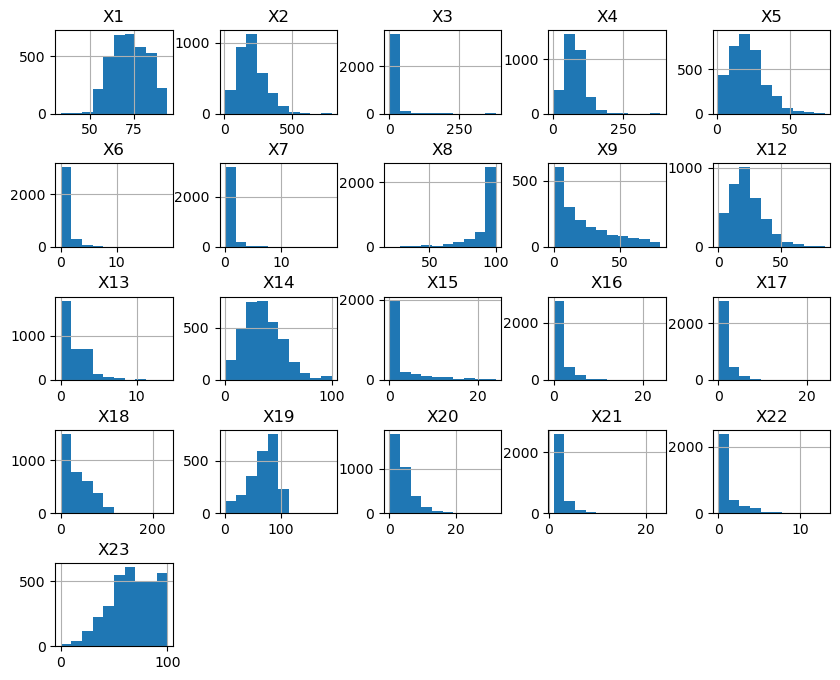

In [11]:
X_train.hist(figsize=(10, 8)) #histogramy
plt.subplots_adjust(hspace=0.6, wspace=0.4) #dopasowanie rozmiarów
plt.savefig("histy.png")
plt.show()

Widzimy, że niektóre rozkłady są prawo lub lewo - skośne i pojawiają się outliery. Skalowaniem zajmiemy się przy poszczególnych modelach.

In [230]:
(y_train["RiskPerformance"]==True).sum() #Zliczamy True w y_train

1924

In [232]:
(y_train["RiskPerformance"]==False).sum() #Zliczamy False w y_train

1736

In [255]:
np.abs((y_train["RiskPerformance"]==True).sum()-(y_train["RiskPerformance"]==False).sum())/((y_train["RiskPerformance"]==True).sum()+(y_train["RiskPerformance"]==False).sum())
#Obliczamy jaką cześć stanowi rożnica liczności klas

0.05136612021857923

Klasy dla y_train mają podobna liczność, różnica około 5%.

## 2. Wybór modelu

### 2.1 DecisionTreeClassifier

In [15]:
numerical_features=['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21', 'X22', 'X23']
categorical_features=['X10', 'X11'] #Rozróżnienie na zmienne numeryczne i kategoryczne

In [438]:
numerical_transformer = Pipeline([ 
    ('imputer', SimpleImputer()),
    ('scaler', StandardScaler())
]) #Uzupełnianie braków danych i skalowanie zmiennych numerycznych

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer()),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]) #Uzupełnianie braków danych i kodowanie zmiennych kategorycznych

preprocessor = ColumnTransformer([
    ('numerical', numerical_transformer, numerical_features),
    ('categorical', categorical_transformer, categorical_features)
]) #przetwarzanie

pipeline = Pipeline([
    ('pre', preprocessor),
    ('tree', DecisionTreeClassifier())
]) #Złączenie w pipeline modelu i przetwarzania danych

In [408]:
#Wybór najlepszego skalowania
params = {
    'pre__numerical__scaler': [StandardScaler(), MinMaxScaler(), MaxAbsScaler(), RobustScaler(), Normalizer(), QuantileTransformer(), PowerTransformer()]
} #określenie parametrów
grid_pipeline = GridSearchCV(pipeline,
                             cv = 7,
                             param_grid = params,
                            scoring="balanced_accuracy") #Wyszukiwanie najlepszych możliwych parametrów na podstawie balanced_accuracy

In [410]:
grid_pipeline.fit(X_train, y_train.RiskPerformance) #Dopasowanie modelu do danych

GridSearchCV(cv=7,
             estimator=Pipeline(steps=[('pre',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['X1',
                                                                          'X2',
                                                                          'X3',
                                                                          'X4',
                                                                          'X5',
                                                                          'X6',
                                                                          'X7',
                                                                          'X8',
                                                                          'X9',
                                                                          'X12',
                                                                          'X13',
                                                                          'X14',
                                                                          'X15',
                                                                          'X16',
                                                                          'X17',
                                                                          'X18',
                                                                          'X19',
                                                                          'X20',
                                                                          'X21',
                                                                          'X22',
                                                                          'X23']),
                                                                        ('categorical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['X10',
                                                                          'X11'])])),
                                       ('tree', DecisionTreeClassifier())]),
             param_grid={'pre__numerical__scaler': [StandardScaler(),
                                                    MinMaxScaler(),
                                                    MaxAbsScaler(),
                                                    RobustScaler(),
                                                    Normalizer(),
                                                    QuantileTransformer(),
                                                    PowerTransformer()]},
             scoring='balanced_accuracy')

In [412]:
grid_pipeline.best_params_ #Wyświetlenie najlepszych parametrów

{'pre__numerical__scaler': PowerTransformer()}

Najlepszym skalowaniem jest PowerTransformer()

In [442]:
#Wybór najlepszego imputera
numerical_transformer = Pipeline([
    ('imputer', SimpleImputer()),
    ('scaler', PowerTransformer())
]) #Uzupełnianie braków danych i skalowanie zmiennych numerycznych

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer()),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]) #Uzupełnianie braków danych i kodowanie zmiennych kategorycznych

preprocessor = ColumnTransformer([
    ('numerical', numerical_transformer, numerical_features),
    ('categorical', categorical_transformer, categorical_features)
]) #przetwarzanie

pipeline = Pipeline([
    ('pre', preprocessor),
    ('tree', DecisionTreeClassifier())
]) #Złączenie w pipeline modelu i przetwarzania danych

In [444]:
params = {
    'pre__numerical__imputer': [SimpleImputer(), KNNImputer()],
    'pre__categorical__imputer': [SimpleImputer(), KNNImputer()],
} #określenie parametrów

grid_pipeline = GridSearchCV(pipeline,
                             cv = 7,
                             param_grid = params,
                            scoring="balanced_accuracy") #Wyszukiwanie najlepszych możliwych parametrów na podstawie balanced_accuracy

In [446]:
grid_pipeline.fit(X_train, y_train.RiskPerformance) #Dopasowanie modelu do danych

GridSearchCV(cv=7,
             estimator=Pipeline(steps=[('pre',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('scaler',
                                                                                          PowerTransformer())]),
                                                                         ['X1',
                                                                          'X2',
                                                                          'X3',
                                                                          'X4',
                                                                          'X5',
                                                                          'X6',
                                                                          'X7',
                                                                          'X8',
                                                                          'X9',
                                                                          'X12',
                                                                          'X13',
                                                                          'X14',
                                                                          'X15',
                                                                          'X16',
                                                                          'X17',
                                                                          'X18',
                                                                          'X19',
                                                                          'X20',
                                                                          'X21',
                                                                          'X22',
                                                                          'X23']),
                                                                        ('categorical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['X10',
                                                                          'X11'])])),
                                       ('tree', DecisionTreeClassifier())]),
             param_grid={'pre__categorical__imputer': [SimpleImputer(),
                                                       KNNImputer(),
                                                       MissingIndicator()],
                         'pre__numerical__imputer': [SimpleImputer(),
                                                     KNNImputer(),
                                                     MissingIndicator()]},
             scoring='balanced_accuracy')

In [448]:
grid_pipeline.best_params_ #Wyświetlenie najlepszych parametrów

{'pre__categorical__imputer': KNNImputer(),
 'pre__numerical__imputer': SimpleImputer()}

Najlepsze imputery to: KNNImputer dla danych kategorycznych i SimpleImputer dla numerycznych

In [462]:
#Wybór najlepszych parametrów dla imputera numerycznego
numerical_transformer = Pipeline([
    ('imputer', SimpleImputer()),
    ('scaler', PowerTransformer())
]) #Uzupełnianie braków danych i skalowanie zmiennych numerycznych

categorical_transformer = Pipeline([
    ('imputer', KNNImputer()),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]) #Uzupełnianie braków danych i kodowanie zmiennych kategorycznych

preprocessor = ColumnTransformer([
    ('numerical', numerical_transformer, numerical_features),
    ('categorical', categorical_transformer, categorical_features)
]) #przetwarzanie

pipeline = Pipeline([
    ('pre', preprocessor),
    ('tree', DecisionTreeClassifier())
]) #Złączenie w pipeline modelu i przetwarzania danych

In [464]:
params = {
    'pre__numerical__imputer__strategy': ['mean', 'most_frequent', 'constant', 'median']
} #określenie parametrów

grid_pipeline = GridSearchCV(pipeline,
                             cv = 7,
                             param_grid = params,
                            scoring="balanced_accuracy") #Wyszukiwanie najlepszych możliwych parametrów na podstawie balanced_accuracy

In [466]:
grid_pipeline.fit(X_train, y_train.RiskPerformance) #Dopasowanie modelu do danych

GridSearchCV(cv=7,
             estimator=Pipeline(steps=[('pre',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('scaler',
                                                                                          PowerTransformer())]),
                                                                         ['X1',
                                                                          'X2',
                                                                          'X3',
                                                                          'X4',
                                                                          'X5',
                                                                          'X6',
                                                                          'X7',
                                                                          'X8',
                                                                          'X9',
                                                                          'X12',
                                                                          'X13',
                                                                          'X14',
                                                                          'X15',
                                                                          'X16',
                                                                          'X17',
                                                                          'X18',
                                                                          'X19',
                                                                          'X20',
                                                                          'X21',
                                                                          'X22',
                                                                          'X23']),
                                                                        ('categorical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          KNNImputer()),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['X10',
                                                                          'X11'])])),
                                       ('tree', DecisionTreeClassifier())]),
             param_grid={'pre__numerical__imputer__strategy': ['mean',
                                                               'most_frequent',
                                                               'constant',
                                                               'median']},
             scoring='balanced_accuracy')

In [468]:
grid_pipeline.best_params_ #Wyświetlenie najlepszych parametrów

{'pre__numerical__imputer__strategy': 'mean'}

Najlepszy parametr to "mean" dla strategy w SimpleImputer

In [471]:
#Wybór najlepszych parametrów dla imputera kategorycznego
numerical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', PowerTransformer())
]) #Uzupełnianie braków danych i skalowanie zmiennych numerycznych

categorical_transformer = Pipeline([
    ('imputer', KNNImputer()),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]) #Uzupełnianie braków danych i kodowanie zmiennych kategorycznych

preprocessor = ColumnTransformer([
    ('numerical', numerical_transformer, numerical_features),
    ('categorical', categorical_transformer, categorical_features)
]) #przetwarzanie

pipeline = Pipeline([
    ('pre', preprocessor),
    ('tree', DecisionTreeClassifier())
]) #Złączenie w pipeline modelu i przetwarzania danych

In [477]:
params = {
    'pre__categorical__imputer__n_neighbors': [3, 5, 7, 9, 11, 13, 15, 20, 30],
    'pre__categorical__imputer__weights': ["uniform", 'distance']
} #określenie parametrów

grid_pipeline = GridSearchCV(pipeline,
                             cv = 7,
                             param_grid = params,
                            scoring="balanced_accuracy") #Wyszukiwanie najlepszych możliwych parametrów na podstawie balanced_accuracy

In [479]:
grid_pipeline.fit(X_train, y_train.RiskPerformance) #Dopasowanie modelu do danych

GridSearchCV(cv=7,
             estimator=Pipeline(steps=[('pre',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('scaler',
                                                                                          PowerTransformer())]),
                                                                         ['X1',
                                                                          'X2',
                                                                          'X3',
                                                                          'X4',
                                                                          'X5',
                                                                          'X6',
                                                                          'X7',
                                                                          'X8',
                                                                          'X9',
                                                                          'X12',
                                                                          'X13',
                                                                          'X14',
                                                                          'X15',
                                                                          'X16',
                                                                          'X17',
                                                                          'X18',
                                                                          'X19',
                                                                          'X20',
                                                                          'X21',
                                                                          'X22',
                                                                          'X23']),
                                                                        ('categorical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          KNNImputer()),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['X10',
                                                                          'X11'])])),
                                       ('tree', DecisionTreeClassifier())]),
             param_grid={'pre__categorical__imputer__n_neighbors': [3, 5, 7, 9,
                                                                    11, 13, 15,
                                                                    20, 30],
                         'pre__categorical__imputer__weights': ['uniform',
                                                                'distance']},
             scoring='balanced_accuracy')

In [481]:
grid_pipeline.best_params_ #Wyświetlenie najlepszych parametrów

{'pre__categorical__imputer__n_neighbors': 20,
 'pre__categorical__imputer__weights': 'distance'}

Najlepsze parametry dla KNNImputer to: n_neighbors=20 i weights='distance'.

In [485]:
#Wybór najlepszych parametrów dla drzewa
numerical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', PowerTransformer())
]) #Uzupełnianie braków danych i skalowanie zmiennych numerycznych

categorical_transformer = Pipeline([
    ('imputer', KNNImputer(n_neighbors=20, weights='distance')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]) #Uzupełnianie braków danych i kodowanie zmiennych kategorycznych

preprocessor = ColumnTransformer([
    ('numerical', numerical_transformer, numerical_features),
    ('categorical', categorical_transformer, categorical_features)
]) #przetwarzanie

pipeline = Pipeline([
    ('pre', preprocessor),
    ('tree', DecisionTreeClassifier())
]) #Złączenie w pipeline modelu i przetwarzania danych

In [489]:
params = {
    'tree__criterion': ['gini', 'entropy'],
    'tree__max_depth': [5, 6, 7, 8, 9, 10, 11, 12, 13],
    'tree__min_samples_leaf': [3, 4, 5, 6, 7, 8, 9, 10]
} #określenie parametrów

grid_pipeline = GridSearchCV(pipeline,
                             cv = 7,
                             param_grid = params,
                            scoring="balanced_accuracy") #Wyszukiwanie najlepszych możliwych parametrów na podstawie balanced_accuracy

In [491]:
grid_pipeline.fit(X_train, y_train.RiskPerformance) #Dopasowanie modelu do danych

GridSearchCV(cv=7,
             estimator=Pipeline(steps=[('pre',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('scaler',
                                                                                          PowerTransformer())]),
                                                                         ['X1',
                                                                          'X2',
                                                                          'X3',
                                                                          'X4',
                                                                          'X5',
                                                                          'X6',
                                                                          'X7',
                                                                          'X8',
                                                                          'X9',
                                                                          'X12',
                                                                          'X13',
                                                                          'X14',
                                                                          'X15',
                                                                          'X16',
                                                                          'X17',
                                                                          'X18',
                                                                          'X19',
                                                                          'X20',
                                                                          'X21',
                                                                          'X22',
                                                                          'X23']),
                                                                        ('categorical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          KNNImputer(n_neighbors=20,
                                                                                                     weights='distance')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['X10',
                                                                          'X11'])])),
                                       ('tree', DecisionTreeClassifier())]),
             param_grid={'tree__criterion': ['gini', 'entropy'],
                         'tree__max_depth': [5, 6, 7, 8, 9, 10, 11, 12, 13],
                         'tree__min_samples_leaf': [3, 4, 5, 6, 7, 8, 9, 10]},
             scoring='balanced_accuracy')

In [493]:
grid_pipeline.best_params_ #Wyświetlenie najlepszych parametrów

{'tree__criterion': 'gini', 'tree__max_depth': 5, 'tree__min_samples_leaf': 3}

Stąd odczytujemy najlepsze parametry.

In [57]:
#Najlepszy model
numerical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', PowerTransformer())
]) #Uzupełnianie braków danych i skalowanie zmiennych numerycznych

categorical_transformer = Pipeline([
    ('imputer', KNNImputer(n_neighbors=20, weights='distance')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]) #Uzupełnianie braków danych i kodowanie zmiennych kategorycznych

preprocessor = ColumnTransformer([
    ('numerical', numerical_transformer, numerical_features),
    ('categorical', categorical_transformer, categorical_features)
]) #przetwarzanie

pipeline_DecisionTree = Pipeline([
    ('pre', preprocessor),
    ('tree', DecisionTreeClassifier(criterion='gini', max_depth=5, min_samples_leaf=3))
]) #Złączenie w pipeline modelu i przetwarzania danych

In [59]:
pipeline_DecisionTree.fit(X_train, y_train.RiskPerformance) #Dopasowanie modelu do danych

Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   PowerTransformer())]),
                                                  ['X1', 'X2', 'X3', 'X4', 'X5',
                                                   'X6', 'X7', 'X8', 'X9',
                                                   'X12', 'X13', 'X14', 'X15',
                                                   'X16', 'X17', 'X18', 'X19',
                                                   'X20', 'X21', 'X22',
                                                   'X23']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer(n_neighbors=20,
                                                                              weights='distance')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['X10', 'X11'])])),
                ('tree',
                 DecisionTreeClassifier(max_depth=5, min_samples_leaf=3))])

In [517]:
y_pred_train=pipeline_DecisionTree.predict(X_train) #Predykcja na zbiorze treningowym

In [519]:
balanced_accuracy_score(y_train.RiskPerformance, y_pred_train) #Obliczenie balanced_accuracy

0.7417414756124434

In [523]:
array=pipeline_DecisionTree.predict_proba(X_test)[:,1]
np.savetxt("output_dec_tree.txt", array.reshape(-1, 1), fmt="%.15f") #zapisanie do pliku wyników predykcji na zbiorze testowym

### 2.2 Regresja logistyczna

In [541]:
numerical_transformer = Pipeline([
    ('imputer', SimpleImputer()),
    ('scaler', StandardScaler())
]) #Uzupełnianie braków danych i skalowanie zmiennych numerycznych

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer()),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]) #Uzupełnianie braków danych i kodowanie zmiennych kategorycznych

preprocessor = ColumnTransformer([
    ('numerical', numerical_transformer, numerical_features),
    ('categorical', categorical_transformer, categorical_features)
]) #przetwarzanie

pipeline = Pipeline([
    ('pre', preprocessor),
    ('tree', LogisticRegression())
]) #Złączenie w pipeline modelu i przetwarzania danych

In [543]:
#Wybór najlepszego skalowania
params = {
    'pre__numerical__scaler': [StandardScaler(), MinMaxScaler(), MaxAbsScaler(), RobustScaler(), Normalizer(), QuantileTransformer(), PowerTransformer()]
} #określenie parametrów
grid_pipeline = GridSearchCV(pipeline,
                             cv = 7,
                             param_grid = params,
                            scoring="balanced_accuracy") #Wyszukiwanie najlepszych możliwych parametrów na podstawie balanced_accuracy

In [549]:
warnings.filterwarnings("ignore")
grid_pipeline.fit(X_train, y_train.RiskPerformance) #Dopasowanie modelu do danych

GridSearchCV(cv=7,
             estimator=Pipeline(steps=[('pre',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['X1',
                                                                          'X2',
                                                                          'X3',
                                                                          'X4',
                                                                          'X5',
                                                                          'X6',
                                                                          'X7',
                                                                          'X8',
                                                                          'X9',
                                                                          'X12',
                                                                          'X13',
                                                                          'X14',
                                                                          'X15',
                                                                          'X16',
                                                                          'X17',
                                                                          'X18',
                                                                          'X19',
                                                                          'X20',
                                                                          'X21',
                                                                          'X22',
                                                                          'X23']),
                                                                        ('categorical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['X10',
                                                                          'X11'])])),
                                       ('tree', LogisticRegression())]),
             param_grid={'pre__numerical__scaler': [StandardScaler(),
                                                    MinMaxScaler(),
                                                    MaxAbsScaler(),
                                                    RobustScaler(),
                                                    Normalizer(),
                                                    QuantileTransformer(),
                                                    PowerTransformer()]},
             scoring='balanced_accuracy')

In [551]:
grid_pipeline.best_params_ #Wyświetlenie najlepszych parametrów

{'pre__numerical__scaler': QuantileTransformer()}

Najlepszym sklaowaniem danych jest QuantileTransformer

In [553]:
#Wybór najlepszego imputera
numerical_transformer = Pipeline([
    ('imputer', SimpleImputer()),
    ('scaler', QuantileTransformer())
]) #Uzupełnianie braków danych i skalowanie zmiennych numerycznych

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer()),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]) #Uzupełnianie braków danych i kodowanie zmiennych kategorycznych

preprocessor = ColumnTransformer([
    ('numerical', numerical_transformer, numerical_features),
    ('categorical', categorical_transformer, categorical_features)
]) #przetwarzanie

pipeline = Pipeline([
    ('pre', preprocessor),
    ('tree', LogisticRegression())
]) #Złączenie w pipeline modelu i przetwarzania danych

In [555]:
params = {
    'pre__numerical__imputer': [SimpleImputer(), KNNImputer()],
    'pre__categorical__imputer': [SimpleImputer(), KNNImputer()],
} #określenie parametrów

grid_pipeline = GridSearchCV(pipeline,
                             cv = 7,
                             param_grid = params,
                            scoring="balanced_accuracy") #Wyszukiwanie najlepszych możliwych parametrów na podstawie balanced_accuracy

In [557]:
grid_pipeline.fit(X_train, y_train.RiskPerformance) #Dopasowanie modelu do danych

GridSearchCV(cv=7,
             estimator=Pipeline(steps=[('pre',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('scaler',
                                                                                          QuantileTransformer())]),
                                                                         ['X1',
                                                                          'X2',
                                                                          'X3',
                                                                          'X4',
                                                                          'X5',
                                                                          'X6',
                                                                          'X7',
                                                                          'X8',
                                                                          'X9',
                                                                          'X12',
                                                                          'X13',
                                                                          'X14',
                                                                          'X15',
                                                                          'X16',
                                                                          'X17',
                                                                          'X18',
                                                                          'X19',
                                                                          'X20',
                                                                          'X21',
                                                                          'X22',
                                                                          'X23']),
                                                                        ('categorical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['X10',
                                                                          'X11'])])),
                                       ('tree', LogisticRegression())]),
             param_grid={'pre__categorical__imputer': [SimpleImputer(),
                                                       KNNImputer()],
                         'pre__numerical__imputer': [SimpleImputer(),
                                                     KNNImputer()]},
             scoring='balanced_accuracy')

In [559]:
grid_pipeline.best_params_ #Wyświetlenie najlepszych parametrów

{'pre__categorical__imputer': SimpleImputer(),
 'pre__numerical__imputer': SimpleImputer()}

Dla obu typów danych SimpleImputer jest najlepszy

In [562]:
#Wybór najlepszych parametrów dla imputera numerycznego i kategorycznego
numerical_transformer = Pipeline([
    ('imputer', SimpleImputer()),
    ('scaler', QuantileTransformer())
]) #Uzupełnianie braków danych i skalowanie zmiennych numerycznych

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer()),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]) #Uzupełnianie braków danych i kodowanie zmiennych kategorycznych

preprocessor = ColumnTransformer([
    ('numerical', numerical_transformer, numerical_features),
    ('categorical', categorical_transformer, categorical_features)
]) #przetwarzanie

pipeline = Pipeline([
    ('pre', preprocessor),
    ('tree', LogisticRegression())
]) #Złączenie w pipeline modelu i przetwarzania danych

In [564]:
params = {
    'pre__numerical__imputer__strategy': ['mean', 'most_frequent', 'constant', 'median'],
    'pre__categorical__imputer__strategy': ['most_frequent', 'constant'],
} #określenie parametrów

grid_pipeline = GridSearchCV(pipeline,
                             cv = 7,
                             param_grid = params,
                            scoring="balanced_accuracy") #Wyszukiwanie najlepszych możliwych parametrów na podstawie balanced_accuracy

In [566]:
grid_pipeline.fit(X_train, y_train.RiskPerformance) #Dopasowanie modelu do danych

GridSearchCV(cv=7,
             estimator=Pipeline(steps=[('pre',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('scaler',
                                                                                          QuantileTransformer())]),
                                                                         ['X1',
                                                                          'X2',
                                                                          'X3',
                                                                          'X4',
                                                                          'X5',
                                                                          'X6',
                                                                          'X7',
                                                                          'X8',
                                                                          'X9',
                                                                          'X12',
                                                                          'X13',
                                                                          'X14',
                                                                          'X15',
                                                                          'X16',
                                                                          'X17',
                                                                          'X18',
                                                                          'X19',
                                                                          'X20',
                                                                          'X21',
                                                                          'X22',
                                                                          'X23']),
                                                                        ('categorical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['X10',
                                                                          'X11'])])),
                                       ('tree', LogisticRegression())]),
             param_grid={'pre__categorical__imputer__strategy': ['most_frequent',
                                                                 'constant'],
                         'pre__numerical__imputer__strategy': ['mean',
                                                               'most_frequent',
                                                               'constant',
                                                               'median']},
             scoring='balanced_accuracy')

In [568]:
grid_pipeline.best_params_ #Wyświetlenie najlepszych parametrów

{'pre__categorical__imputer__strategy': 'most_frequent',
 'pre__numerical__imputer__strategy': 'median'}

Stąd odczutujemy najlepsze parametry

In [571]:
#Wybór najlepszych parametrów dla regresji logistycznej
numerical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', QuantileTransformer())
]) #Uzupełnianie braków danych i skalowanie zmiennych numerycznych

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]) #Uzupełnianie braków danych i kodowanie zmiennych kategorycznych

preprocessor = ColumnTransformer([
    ('numerical', numerical_transformer, numerical_features),
    ('categorical', categorical_transformer, categorical_features)
]) #przetwarzanie

pipeline = Pipeline([
    ('pre', preprocessor),
    ('tree', LogisticRegression())
]) #Złączenie w pipeline modelu i przetwarzania danych

In [577]:
#Wybór penalty, tol class_weight oraz max_iter
params = {
    'tree__penalty': ['l1', 'l2', 'elasticnet', None],
    'tree__tol': [1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1],
    'tree__class_weight': ["balanced", None],
    'tree__max_iter': [50, 150, 250, 350, 450]
} #określenie parametrów

grid_pipeline = GridSearchCV(pipeline,
                             cv = 3,
                             param_grid = params,
                            scoring="balanced_accuracy") #Wyszukiwanie najlepszych możliwych parametrów na podstawie balanced_accuracy

In [579]:
grid_pipeline.fit(X_train, y_train.RiskPerformance) #Dopasowanie modelu do danych

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('pre',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          QuantileTransformer())]),
                                                                         ['X1',
                                                                          'X2',
                                                                          'X3',
                                                                          'X4',
                                                                          'X5',
                                                                          'X6',
                                                                          'X7',
                                                                          'X8',
                                                                          'X9',
                                                                          'X12',
                                                                          'X13',
                                                                          'X14',
                                                                          'X15',
                                                                          'X16',
                                                                          'X17',
                                                                          'X18',
                                                                          'X19',
                                                                          'X20',
                                                                          'X21',
                                                                          'X22',
                                                                          'X23']),
                                                                        ('categorical',
                                                                         Pipeline(steps=[('imput...
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['X10',
                                                                          'X11'])])),
                                       ('tree', LogisticRegression())]),
             param_grid={'tree__class_weight': ['balanced', None],
                         'tree__max_iter': [50, 150, 250, 350, 450],
                         'tree__penalty': ['l1', 'l2', 'elasticnet', None],
                         'tree__tol': [1e-07, 1e-06, 1e-05, 0.0001, 0.001, 0.01,
                                       0.1]},
             scoring='balanced_accuracy')

In [581]:
grid_pipeline.best_params_ #Wyświetlenie najlepszych parametrów

{'tree__class_weight': 'balanced',
 'tree__max_iter': 50,
 'tree__penalty': 'l2',
 'tree__tol': 0.001}

Stąd odczytujemy część najlepszych parametrów.

In [586]:
#Wybór najlepszych parametrów dla regresji logistycznej z regularyzacją l2
numerical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', QuantileTransformer())
]) #Uzupełnianie braków danych i skalowanie zmiennych numerycznych

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]) #Uzupełnianie braków danych i kodowanie zmiennych kategorycznych

preprocessor = ColumnTransformer([
    ('numerical', numerical_transformer, numerical_features),
    ('categorical', categorical_transformer, categorical_features)
]) #przetwarzanie

pipeline = Pipeline([
    ('pre', preprocessor),
    ('tree', LogisticRegression(class_weight='balanced', max_iter=50, penalty='l2', tol=0.001))
]) #Złączenie w pipeline modelu i przetwarzania danych

In [588]:
params = {
    'tree__C': [0.01, 0.1, 1, 10, 100],
    'tree__solver': ['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga']
} #określenie parametrów

grid_pipeline = GridSearchCV(pipeline,
                             cv = 7,
                             param_grid = params,
                            scoring="balanced_accuracy") #Wyszukiwanie najlepszych możliwych parametrów na podstawie balanced_accuracy

In [590]:
grid_pipeline.fit(X_train, y_train.RiskPerformance) #Dopasowanie modelu do danych

GridSearchCV(cv=7,
             estimator=Pipeline(steps=[('pre',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          QuantileTransformer())]),
                                                                         ['X1',
                                                                          'X2',
                                                                          'X3',
                                                                          'X4',
                                                                          'X5',
                                                                          'X6',
                                                                          'X7',
                                                                          'X8',
                                                                          'X9',
                                                                          'X12',
                                                                          'X13',
                                                                          'X14',
                                                                          'X15',
                                                                          'X16',
                                                                          'X17',
                                                                          'X18',
                                                                          'X19',
                                                                          'X20',
                                                                          'X21',
                                                                          'X22',
                                                                          'X23']),
                                                                        ('categorical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['X10',
                                                                          'X11'])])),
                                       ('tree',
                                        LogisticRegression(class_weight='balanced',
                                                           max_iter=50,
                                                           tol=0.001))]),
             param_grid={'tree__C': [0.01, 0.1, 1, 10, 100],
                         'tree__solver': ['lbfgs', 'liblinear', 'newton-cg',
                                          'newton-cholesky', 'sag', 'saga']},
             scoring='balanced_accuracy')

In [592]:
grid_pipeline.best_params_ #Wyświetlenie najlepszych parametrów

{'tree__C': 1, 'tree__solver': 'lbfgs'}

Stąd odczytujemy resztę parametrów

In [61]:
#Najlepszy model
numerical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', QuantileTransformer())
]) #Uzupełnianie braków danych i skalowanie zmiennych numerycznych

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]) #Uzupełnianie braków danych i kodowanie zmiennych kategorycznych

preprocessor = ColumnTransformer([
    ('numerical', numerical_transformer, numerical_features),
    ('categorical', categorical_transformer, categorical_features)
]) #przetwarzanie

pipeline_LogisticRegression = Pipeline([
    ('pre', preprocessor),
    ('tree', LogisticRegression(class_weight='balanced', max_iter=50, penalty='l2', tol=0.001, C=1, solver='lbfgs'))
]) #Złączenie w pipeline modelu i przetwarzania danych

In [63]:
pipeline_LogisticRegression.fit(X_train, y_train.RiskPerformance) #Dopasowanie modelu do danych

Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   QuantileTransformer())]),
                                                  ['X1', 'X2', 'X3', 'X4', 'X5',
                                                   'X6', 'X7', 'X8', 'X9',
                                                   'X12', 'X13', 'X14', 'X15',
                                                   'X16', 'X17', 'X18', 'X19',
                                                   'X20', 'X21', 'X22',
                                                   'X23']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['X10', 'X11'])])),
                ('tree',
                 LogisticRegression(C=1, class_weight='balanced', max_iter=50,
                                    tol=0.001))])

In [601]:
y_pred_train=pipeline_LogisticRegression.predict(X_train) #Predykcja na zbiorze treningowym

In [603]:
balanced_accuracy_score(y_train.RiskPerformance, y_pred_train) #Obliczenie balanced_accuracy

0.7363074480009963

In [ ]:
#SVC, LDA, QDA, BernoulliNB, KNN, PCA, RandomForestClassifier, BaggingClassifier, ExtraTreesClassifier, GradientBoostingClassifier, VotingClassifier, StackingClassifie

### 2.3 SVM

In [16]:
#Wybór najlepszego skalowania
numerical_transformer = Pipeline([
    ('imputer', SimpleImputer()),
    ('scaler', StandardScaler())
]) #Uzupełnianie braków danych i skalowanie zmiennych numerycznych

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer()),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]) #Uzupełnianie braków danych i kodowanie zmiennych kategorycznych

preprocessor = ColumnTransformer([
    ('numerical', numerical_transformer, numerical_features),
    ('categorical', categorical_transformer, categorical_features)
]) #przetwarzanie

pipeline= Pipeline([
    ('pre', preprocessor),
    ('tree', SVC())
]) #Złączenie w pipeline modelu i przetwarzania danych

In [18]:
#Wybór najlepszego skalowania
params = {
    'pre__numerical__scaler': [StandardScaler(), MinMaxScaler(), MaxAbsScaler(), RobustScaler(), Normalizer(), QuantileTransformer(), PowerTransformer()]
} #określenie parametrów
grid_pipeline = GridSearchCV(pipeline,
                             cv = 7,
                             param_grid = params,
                            scoring="balanced_accuracy") #Wyszukiwanie najlepszych możliwych parametrów na podstawie balanced_accuracy

In [20]:
grid_pipeline.fit(X_train, y_train.RiskPerformance) #Dopasowanie modelu do danych

GridSearchCV(cv=7,
             estimator=Pipeline(steps=[('pre',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['X1',
                                                                          'X2',
                                                                          'X3',
                                                                          'X4',
                                                                          'X5',
                                                                          'X6',
                                                                          'X7',
                                                                          'X8',
                                                                          'X9',
                                                                          'X12',
                                                                          'X13',
                                                                          'X14',
                                                                          'X15',
                                                                          'X16',
                                                                          'X17',
                                                                          'X18',
                                                                          'X19',
                                                                          'X20',
                                                                          'X21',
                                                                          'X22',
                                                                          'X23']),
                                                                        ('categorical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['X10',
                                                                          'X11'])])),
                                       ('tree', SVC())]),
             param_grid={'pre__numerical__scaler': [StandardScaler(),
                                                    MinMaxScaler(),
                                                    MaxAbsScaler(),
                                                    RobustScaler(),
                                                    Normalizer(),
                                                    QuantileTransformer(),
                                                    PowerTransformer()]},
             scoring='balanced_accuracy')

In [22]:
grid_pipeline.best_params_ #Wyświetlenie najlepszych parametrów

{'pre__numerical__scaler': PowerTransformer()}

Wybieramy PowerTransformer

In [27]:
#Wybór najlepszych imputerów
numerical_transformer = Pipeline([
    ('imputer', SimpleImputer()),
    ('scaler', PowerTransformer())
]) #Uzupełnianie braków danych i skalowanie zmiennych numerycznych

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer()),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]) #Uzupełnianie braków danych i kodowanie zmiennych kategorycznych

preprocessor = ColumnTransformer([
    ('numerical', numerical_transformer, numerical_features),
    ('categorical', categorical_transformer, categorical_features)
]) #przetwarzanie

pipeline= Pipeline([
    ('pre', preprocessor),
    ('tree', SVC())
]) #Złączenie w pipeline modelu i przetwarzania danych

In [29]:
params = {
    'pre__numerical__imputer': [SimpleImputer(), KNNImputer()],
    'pre__categorical__imputer': [SimpleImputer(), KNNImputer()],
} #określenie parametrów

grid_pipeline = GridSearchCV(pipeline,
                             cv = 7,
                             param_grid = params,
                            scoring="balanced_accuracy") #Wyszukiwanie najlepszych możliwych parametrów na podstawie balanced_accuracy

In [31]:
grid_pipeline.fit(X_train, y_train.RiskPerformance) #Dopasowanie modelu do danych

GridSearchCV(cv=7,
             estimator=Pipeline(steps=[('pre',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('scaler',
                                                                                          PowerTransformer())]),
                                                                         ['X1',
                                                                          'X2',
                                                                          'X3',
                                                                          'X4',
                                                                          'X5',
                                                                          'X6',
                                                                          'X7',
                                                                          'X8',
                                                                          'X9',
                                                                          'X12',
                                                                          'X13',
                                                                          'X14',
                                                                          'X15',
                                                                          'X16',
                                                                          'X17',
                                                                          'X18',
                                                                          'X19',
                                                                          'X20',
                                                                          'X21',
                                                                          'X22',
                                                                          'X23']),
                                                                        ('categorical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['X10',
                                                                          'X11'])])),
                                       ('tree', SVC())]),
             param_grid={'pre__categorical__imputer': [SimpleImputer(),
                                                       KNNImputer()],
                         'pre__numerical__imputer': [SimpleImputer(),
                                                     KNNImputer()]},
             scoring='balanced_accuracy')

In [33]:
grid_pipeline.best_params_ #Wyświetlenie najlepszych parametrów

{'pre__categorical__imputer': SimpleImputer(),
 'pre__numerical__imputer': SimpleImputer()}

Wybieramy SimpleImputer dla obu

In [37]:
#Wybór najlepszych parametrów dla obu imputerów
numerical_transformer = Pipeline([
    ('imputer', SimpleImputer()),
    ('scaler', PowerTransformer())
]) #Uzupełnianie braków danych i skalowanie zmiennych numerycznych

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer()),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]) #Uzupełnianie braków danych i kodowanie zmiennych kategorycznych

preprocessor = ColumnTransformer([
    ('numerical', numerical_transformer, numerical_features),
    ('categorical', categorical_transformer, categorical_features)
]) #przetwarzanie

pipeline= Pipeline([
    ('pre', preprocessor),
    ('tree', SVC())
]) #Złączenie w pipeline modelu i przetwarzania danych

In [39]:
params = {
    'pre__numerical__imputer__strategy': ['mean', 'most_frequent', 'constant', 'median'],
    'pre__categorical__imputer__strategy': ['most_frequent', 'constant'],
} #określenie parametrów

grid_pipeline = GridSearchCV(pipeline,
                             cv = 7,
                             param_grid = params,
                            scoring="balanced_accuracy") #Wyszukiwanie najlepszych możliwych parametrów na podstawie balanced_accuracy

In [41]:
grid_pipeline.fit(X_train, y_train.RiskPerformance) #Dopasowanie modelu do danych

GridSearchCV(cv=7,
             estimator=Pipeline(steps=[('pre',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('scaler',
                                                                                          PowerTransformer())]),
                                                                         ['X1',
                                                                          'X2',
                                                                          'X3',
                                                                          'X4',
                                                                          'X5',
                                                                          'X6',
                                                                          'X7',
                                                                          'X8',
                                                                          'X9',
                                                                          'X12',
                                                                          'X13',
                                                                          'X14',
                                                                          'X15',
                                                                          'X16',
                                                                          'X17',
                                                                          'X18',
                                                                          'X19',
                                                                          'X20',
                                                                          'X21',
                                                                          'X22',
                                                                          'X23']),
                                                                        ('categorical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['X10',
                                                                          'X11'])])),
                                       ('tree', SVC())]),
             param_grid={'pre__categorical__imputer__strategy': ['most_frequent',
                                                                 'constant'],
                         'pre__numerical__imputer__strategy': ['mean',
                                                               'most_frequent',
                                                               'constant',
                                                               'median']},
             scoring='balanced_accuracy')

In [43]:
grid_pipeline.best_params_ #Wyświetlenie najlepszych parametrów

{'pre__categorical__imputer__strategy': 'constant',
 'pre__numerical__imputer__strategy': 'constant'}

In [47]:
#Wybór cześci najlepszych parametrów dla SVM
numerical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant')),
    ('scaler', PowerTransformer())
]) #Uzupełnianie braków danych i skalowanie zmiennych numerycznych

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]) #Uzupełnianie braków danych i kodowanie zmiennych kategorycznych

preprocessor = ColumnTransformer([
    ('numerical', numerical_transformer, numerical_features),
    ('categorical', categorical_transformer, categorical_features)
]) #przetwarzanie

pipeline= Pipeline([
    ('pre', preprocessor),
    ('tree', SVC())
]) #Złączenie w pipeline modelu i przetwarzania danych

In [68]:
params = {
    'tree__kernel': ['linear', 'poly', 'rbf', 'sigmoid', 'precomputed'],
    'tree__C': [0.01, 0.1, 1, 10, 100]
    
} #określenie parametrów

grid_pipeline = GridSearchCV(pipeline,
                             cv = 3,
                             param_grid = params,
                            scoring="balanced_accuracy") #Wyszukiwanie najlepszych możliwych parametrów na podstawie balanced_accuracy

In [70]:
warnings.filterwarnings("ignore")
grid_pipeline.fit(X_train, y_train.RiskPerformance) #Dopasowanie modelu do danych

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('pre',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='constant')),
                                                                                         ('scaler',
                                                                                          PowerTransformer())]),
                                                                         ['X1',
                                                                          'X2',
                                                                          'X3',
                                                                          'X4',
                                                                          'X5',
                                                                          'X6',
                                                                          'X7',
                                                                          'X8',
                                                                          'X9',
                                                                          'X12',
                                                                          'X13',
                                                                          'X14',
                                                                          'X15',
                                                                          'X16',
                                                                          'X17',
                                                                          'X18',
                                                                          'X19',
                                                                          'X20',
                                                                          'X21',
                                                                          'X22',
                                                                          'X23']),
                                                                        ('categorical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='constant')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['X10',
                                                                          'X11'])])),
                                       ('tree', SVC())]),
             param_grid={'tree__C': [0.01, 0.1, 1, 10, 100],
                         'tree__kernel': ['linear', 'poly', 'rbf', 'sigmoid',
                                          'precomputed']},
             scoring='balanced_accuracy')

In [72]:
grid_pipeline.best_params_ #Wyświetlenie najlepszych parametrów

{'tree__C': 10, 'tree__kernel': 'linear'}

Stąd bierzemy część parametrów.

In [79]:
#Wybór reszty najlepszych parametrów dla SVM
numerical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant')),
    ('scaler', PowerTransformer())
]) #Uzupełnianie braków danych i skalowanie zmiennych numerycznych

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]) #Uzupełnianie braków danych i kodowanie zmiennych kategorycznych

preprocessor = ColumnTransformer([
    ('numerical', numerical_transformer, numerical_features),
    ('categorical', categorical_transformer, categorical_features)
]) #przetwarzanie

pipeline= Pipeline([
    ('pre', preprocessor),
    ('tree', SVC(C=10, kernel='linear'))
]) #Złączenie w pipeline modelu i przetwarzania danych

In [81]:
params = {
    'tree__tol': [1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1],
    'tree__class_weight': ["balanced", None],
    'tree__max_iter': [50, 150, 250, 350, 450]
    
} #określenie parametrów

grid_pipeline = GridSearchCV(pipeline,
                             cv = 3,
                             param_grid = params,
                            scoring="balanced_accuracy") #Wyszukiwanie najlepszych możliwych parametrów na podstawie balanced_accuracy

In [83]:
warnings.filterwarnings("ignore")
grid_pipeline.fit(X_train, y_train.RiskPerformance) #Dopasowanie modelu do danych

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('pre',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='constant')),
                                                                                         ('scaler',
                                                                                          PowerTransformer())]),
                                                                         ['X1',
                                                                          'X2',
                                                                          'X3',
                                                                          'X4',
                                                                          'X5',
                                                                          'X6',
                                                                          'X7',
                                                                          'X8',
                                                                          'X9',
                                                                          'X12',
                                                                          'X13',
                                                                          'X14',
                                                                          'X15',
                                                                          'X16',
                                                                          'X17',
                                                                          'X18',
                                                                          'X19',
                                                                          'X20',
                                                                          'X21',
                                                                          'X22',
                                                                          'X23']),
                                                                        ('categorical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='constant')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['X10',
                                                                          'X11'])])),
                                       ('tree', SVC(C=10, kernel='linear'))]),
             param_grid={'tree__class_weight': ['balanced', None],
                         'tree__max_iter': [50, 150, 250, 350, 450],
                         'tree__tol': [1e-07, 1e-06, 1e-05, 0.0001, 0.001, 0.01,
                                       0.1]},
             scoring='balanced_accuracy')

In [85]:
grid_pipeline.best_params_ #Wyświetlenie najlepszych parametrów

{'tree__class_weight': None, 'tree__max_iter': 250, 'tree__tol': 1e-07}

Stąd odczytujemy najlepsze parametry

In [65]:
#Najlepszy model
numerical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant')),
    ('scaler', PowerTransformer())
]) #Uzupełnianie braków danych i skalowanie zmiennych numerycznych

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]) #Uzupełnianie braków danych i kodowanie zmiennych kategorycznych

preprocessor = ColumnTransformer([
    ('numerical', numerical_transformer, numerical_features),
    ('categorical', categorical_transformer, categorical_features)
]) #przetwarzanie

pipeline_svm= Pipeline([
    ('pre', preprocessor),
    ('tree', SVC(C=10, kernel='linear', class_weight=None, max_iter=250, tol=1e-07))
]) #Złączenie w pipeline modelu i przetwarzania danych

In [77]:
warnings.filterwarnings("ignore")
pipeline_svm.fit(X_train, y_train.RiskPerformance) #Dopasowanie modelu do danych

Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='constant')),
                                                                  ('scaler',
                                                                   PowerTransformer())]),
                                                  ['X1', 'X2', 'X3', 'X4', 'X5',
                                                   'X6', 'X7', 'X8', 'X9',
                                                   'X12', 'X13', 'X14', 'X15',
                                                   'X16', 'X17', 'X18', 'X19',
                                                   'X20', 'X21', 'X22',
                                                   'X23']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['X10', 'X11'])])),
                ('tree', SVC(C=10, kernel='linear', max_iter=250, tol=1e-07))])

In [94]:
y_pred_train=pipeline_svm.predict(X_train) #Predykcja na zbiorze treningowym

In [96]:
balanced_accuracy_score(y_train.RiskPerformance, y_pred_train) #Obliczenie balanced_accuracy

0.5723081952920663

### 2.4 LDA

In [104]:
#Wybór najlepszego skalowania
numerical_transformer = Pipeline([
    ('imputer', SimpleImputer()),
    ('scaler', StandardScaler())
]) #Uzupełnianie braków danych i skalowanie zmiennych numerycznych

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer()),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]) #Uzupełnianie braków danych i kodowanie zmiennych kategorycznych

preprocessor = ColumnTransformer([
    ('numerical', numerical_transformer, numerical_features),
    ('categorical', categorical_transformer, categorical_features)
]) #przetwarzanie

pipeline= Pipeline([
    ('pre', preprocessor),
    ('tree', LinearDiscriminantAnalysis())
]) #Złączenie w pipeline modelu i przetwarzania danych

In [106]:
#Wybór najlepszego skalowania
params = {
    'pre__numerical__scaler': [StandardScaler(), MinMaxScaler(), MaxAbsScaler(), RobustScaler(), Normalizer(), QuantileTransformer(), PowerTransformer()]
} #określenie parametrów
grid_pipeline = GridSearchCV(pipeline,
                             cv = 7,
                             param_grid = params,
                            scoring="balanced_accuracy") #Wyszukiwanie najlepszych możliwych parametrów na podstawie balanced_accuracy

In [108]:
grid_pipeline.fit(X_train, y_train.RiskPerformance) #Dopasowanie modelu do danych

GridSearchCV(cv=7,
             estimator=Pipeline(steps=[('pre',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['X1',
                                                                          'X2',
                                                                          'X3',
                                                                          'X4',
                                                                          'X5',
                                                                          'X6',
                                                                          'X7',
                                                                          'X8',
                                                                          'X9',
                                                                          'X12',
                                                                          'X13',
                                                                          'X14',
                                                                          'X15',
                                                                          'X16',
                                                                          'X17',
                                                                          'X18',
                                                                          'X19',
                                                                          'X20',
                                                                          'X21',
                                                                          'X22',
                                                                          'X23']),
                                                                        ('categorical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['X10',
                                                                          'X11'])])),
                                       ('tree', LinearDiscriminantAnalysis())]),
             param_grid={'pre__numerical__scaler': [StandardScaler(),
                                                    MinMaxScaler(),
                                                    MaxAbsScaler(),
                                                    RobustScaler(),
                                                    Normalizer(),
                                                    QuantileTransformer(),
                                                    PowerTransformer()]},
             scoring='balanced_accuracy')

In [110]:
grid_pipeline.best_params_ #Wyświetlenie najlepszych parametrów

{'pre__numerical__scaler': PowerTransformer()}

Wybiermay PowerTransformer

In [113]:
#Wybór najlepszych imputerów
numerical_transformer = Pipeline([
    ('imputer', SimpleImputer()),
    ('scaler', PowerTransformer())
]) #Uzupełnianie braków danych i skalowanie zmiennych numerycznych

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer()),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]) #Uzupełnianie braków danych i kodowanie zmiennych kategorycznych

preprocessor = ColumnTransformer([
    ('numerical', numerical_transformer, numerical_features),
    ('categorical', categorical_transformer, categorical_features)
]) #przetwarzanie

pipeline= Pipeline([
    ('pre', preprocessor),
    ('tree', LinearDiscriminantAnalysis())
]) #Złączenie w pipeline modelu i przetwarzania danych

In [115]:
params = {
    'pre__numerical__imputer': [SimpleImputer(), KNNImputer()],
    'pre__categorical__imputer': [SimpleImputer(), KNNImputer()],
} #określenie parametrów

grid_pipeline = GridSearchCV(pipeline,
                             cv = 7,
                             param_grid = params,
                            scoring="balanced_accuracy") #Wyszukiwanie najlepszych możliwych parametrów na podstawie balanced_accuracy

In [117]:
grid_pipeline.fit(X_train, y_train.RiskPerformance) #Dopasowanie modelu do danych

GridSearchCV(cv=7,
             estimator=Pipeline(steps=[('pre',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('scaler',
                                                                                          PowerTransformer())]),
                                                                         ['X1',
                                                                          'X2',
                                                                          'X3',
                                                                          'X4',
                                                                          'X5',
                                                                          'X6',
                                                                          'X7',
                                                                          'X8',
                                                                          'X9',
                                                                          'X12',
                                                                          'X13',
                                                                          'X14',
                                                                          'X15',
                                                                          'X16',
                                                                          'X17',
                                                                          'X18',
                                                                          'X19',
                                                                          'X20',
                                                                          'X21',
                                                                          'X22',
                                                                          'X23']),
                                                                        ('categorical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['X10',
                                                                          'X11'])])),
                                       ('tree', LinearDiscriminantAnalysis())]),
             param_grid={'pre__categorical__imputer': [SimpleImputer(),
                                                       KNNImputer()],
                         'pre__numerical__imputer': [SimpleImputer(),
                                                     KNNImputer()]},
             scoring='balanced_accuracy')

In [119]:
grid_pipeline.best_params_ #Wyświetlenie najlepszych parametrów

{'pre__categorical__imputer': SimpleImputer(),
 'pre__numerical__imputer': KNNImputer()}

Dla kategorycznych bierzemy SimpleImputer, a dla numerycznych KNNImputer

In [138]:
#Wybór najlepszych parametrów dla obu imputerów
numerical_transformer = Pipeline([
    ('imputer', KNNImputer()),
    ('scaler', PowerTransformer())
]) #Uzupełnianie braków danych i skalowanie zmiennych numerycznych

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer()),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]) #Uzupełnianie braków danych i kodowanie zmiennych kategorycznych

preprocessor = ColumnTransformer([
    ('numerical', numerical_transformer, numerical_features),
    ('categorical', categorical_transformer, categorical_features)
]) #przetwarzanie

pipeline= Pipeline([
    ('pre', preprocessor),
    ('tree', LinearDiscriminantAnalysis())
]) #Złączenie w pipeline modelu i przetwarzania danych

In [140]:
params = {
    'pre__numerical__imputer__n_neighbors': [3, 5, 7, 9, 11, 13, 15, 20, 30],
    'pre__numerical__imputer__weights': ["uniform", 'distance'],
    'pre__categorical__imputer__strategy': ['most_frequent', 'constant'],
    
} #określenie parametrów

grid_pipeline = GridSearchCV(pipeline,
                             cv = 7,
                             param_grid = params,
                            scoring="balanced_accuracy") #Wyszukiwanie najlepszych możliwych parametrów na podstawie balanced_accuracy

In [142]:
grid_pipeline.fit(X_train, y_train.RiskPerformance) #Dopasowanie modelu do danych

GridSearchCV(cv=7,
             estimator=Pipeline(steps=[('pre',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          KNNImputer()),
                                                                                         ('scaler',
                                                                                          PowerTransformer())]),
                                                                         ['X1',
                                                                          'X2',
                                                                          'X3',
                                                                          'X4',
                                                                          'X5',
                                                                          'X6',
                                                                          'X7',
                                                                          'X8',
                                                                          'X9',
                                                                          'X12',
                                                                          'X13',
                                                                          'X14',
                                                                          'X15',
                                                                          'X16',
                                                                          'X17',
                                                                          'X18',
                                                                          'X19',
                                                                          'X20',
                                                                          'X21',
                                                                          'X22',
                                                                          'X23']),
                                                                        ('categorical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['X10',
                                                                          'X11'])])),
                                       ('tree', LinearDiscriminantAnalysis())]),
             param_grid={'pre__categorical__imputer__strategy': ['most_frequent',
                                                                 'constant'],
                         'pre__numerical__imputer__n_neighbors': [3, 5, 7, 9,
                                                                  11, 13, 15,
                                                                  20, 30],
                         'pre__numerical__imputer__weights': ['uniform',
                                                              'distance']},
             scoring='balanced_accuracy')

In [144]:
grid_pipeline.best_params_ #Wyświetlenie najlepszych parametrów

{'pre__categorical__imputer__strategy': 'most_frequent',
 'pre__numerical__imputer__n_neighbors': 5,
 'pre__numerical__imputer__weights': 'distance'}

Stąd bierzemy parametry

In [146]:
#Wybór najlepszych parametrów dla LDA
numerical_transformer = Pipeline([
    ('imputer', KNNImputer(n_neighbors=5, weights='distance')),
    ('scaler', PowerTransformer())
]) #Uzupełnianie braków danych i skalowanie zmiennych numerycznych

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]) #Uzupełnianie braków danych i kodowanie zmiennych kategorycznych

preprocessor = ColumnTransformer([
    ('numerical', numerical_transformer, numerical_features),
    ('categorical', categorical_transformer, categorical_features)
]) #przetwarzanie

pipeline= Pipeline([
    ('pre', preprocessor),
    ('tree', LinearDiscriminantAnalysis())
]) #Złączenie w pipeline modelu i przetwarzania danych

In [148]:
params = {
    'tree__solver': ['svd', 'lsqr', 'eigen'],
    'tree__tol': [1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1]
    
} #określenie parametrów

grid_pipeline = GridSearchCV(pipeline,
                             cv = 7,
                             param_grid = params,
                            scoring="balanced_accuracy") #Wyszukiwanie najlepszych możliwych parametrów na podstawie balanced_accuracy

In [150]:
grid_pipeline.fit(X_train, y_train.RiskPerformance) #Dopasowanie modelu do danych

GridSearchCV(cv=7,
             estimator=Pipeline(steps=[('pre',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          KNNImputer(weights='distance')),
                                                                                         ('scaler',
                                                                                          PowerTransformer())]),
                                                                         ['X1',
                                                                          'X2',
                                                                          'X3',
                                                                          'X4',
                                                                          'X5',
                                                                          'X6',
                                                                          'X7',
                                                                          'X8',
                                                                          'X9',
                                                                          'X12',
                                                                          'X13',
                                                                          'X14',
                                                                          'X15',
                                                                          'X16',
                                                                          'X17',
                                                                          'X18',
                                                                          'X19',
                                                                          'X20',
                                                                          'X21',
                                                                          'X22',
                                                                          'X23']),
                                                                        ('categorical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['X10',
                                                                          'X11'])])),
                                       ('tree', LinearDiscriminantAnalysis())]),
             param_grid={'tree__solver': ['svd', 'lsqr', 'eigen'],
                         'tree__tol': [1e-07, 1e-06, 1e-05, 0.0001, 0.001, 0.01,
                                       0.1]},
             scoring='balanced_accuracy')

In [151]:
grid_pipeline.best_params_ #Wyświetlenie najlepszych parametrów

{'tree__solver': 'svd', 'tree__tol': 1e-07}

In [69]:
#Najlepszy model
numerical_transformer = Pipeline([
    ('imputer', KNNImputer(n_neighbors=5, weights='distance')),
    ('scaler', PowerTransformer())
]) #Uzupełnianie braków danych i skalowanie zmiennych numerycznych

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]) #Uzupełnianie braków danych i kodowanie zmiennych kategorycznych

preprocessor = ColumnTransformer([
    ('numerical', numerical_transformer, numerical_features),
    ('categorical', categorical_transformer, categorical_features)
]) #przetwarzanie

pipeline_lda= Pipeline([
    ('pre', preprocessor),
    ('tree', LinearDiscriminantAnalysis(solver='svd', tol=1e-07))
]) #Złączenie w pipeline modelu i przetwarzania danych

In [71]:
pipeline_lda.fit(X_train, y_train.RiskPerformance) #Dopasowanie modelu do danych

Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer(weights='distance')),
                                                                  ('scaler',
                                                                   PowerTransformer())]),
                                                  ['X1', 'X2', 'X3', 'X4', 'X5',
                                                   'X6', 'X7', 'X8', 'X9',
                                                   'X12', 'X13', 'X14', 'X15',
                                                   'X16', 'X17', 'X18', 'X19',
                                                   'X20', 'X21', 'X22',
                                                   'X23']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['X10', 'X11'])])),
                ('tree', LinearDiscriminantAnalysis(tol=1e-07))])

In [162]:
y_pred_train=pipeline_lda.predict(X_train) #Predykcja na zbiorze treningowym

In [164]:
balanced_accuracy_score(y_train.RiskPerformance, y_pred_train) #Obliczenie balanced_accuracy

0.7308333013978174

### 2.5 QDA

In [170]:
#Wybór najlepszego skalowania
numerical_transformer = Pipeline([
    ('imputer', SimpleImputer()),
    ('scaler', StandardScaler())
]) #Uzupełnianie braków danych i skalowanie zmiennych numerycznych

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer()),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]) #Uzupełnianie braków danych i kodowanie zmiennych kategorycznych

preprocessor = ColumnTransformer([
    ('numerical', numerical_transformer, numerical_features),
    ('categorical', categorical_transformer, categorical_features)
]) #przetwarzanie

pipeline= Pipeline([
    ('pre', preprocessor),
    ('tree', QuadraticDiscriminantAnalysis())
]) #Złączenie w pipeline modelu i przetwarzania danych

In [172]:
#Wybór najlepszego skalowania
params = {
    'pre__numerical__scaler': [StandardScaler(), MinMaxScaler(), MaxAbsScaler(), RobustScaler(), Normalizer(), QuantileTransformer(), PowerTransformer()]
} #określenie parametrów
grid_pipeline = GridSearchCV(pipeline,
                             cv = 7,
                             param_grid = params,
                            scoring="balanced_accuracy") #Wyszukiwanie najlepszych możliwych parametrów na podstawie balanced_accuracy

In [174]:
grid_pipeline.fit(X_train, y_train.RiskPerformance) #Dopasowanie modelu do danych

GridSearchCV(cv=7,
             estimator=Pipeline(steps=[('pre',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['X1',
                                                                          'X2',
                                                                          'X3',
                                                                          'X4',
                                                                          'X5',
                                                                          'X6',
                                                                          'X7',
                                                                          'X8',
                                                                          'X9',
                                                                          'X12',
                                                                          'X13',
                                                                          'X14',
                                                                          'X15',
                                                                          'X16',
                                                                          'X17',
                                                                          'X18',
                                                                          'X19',
                                                                          'X20',
                                                                          'X21',
                                                                          'X22',
                                                                          'X23']),
                                                                        ('categorical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['X10',
                                                                          'X11'])])),
                                       ('tree',
                                        QuadraticDiscriminantAnalysis())]),
             param_grid={'pre__numerical__scaler': [StandardScaler(),
                                                    MinMaxScaler(),
                                                    MaxAbsScaler(),
                                                    RobustScaler(),
                                                    Normalizer(),
                                                    QuantileTransformer(),
                                                    PowerTransformer()]},
             scoring='balanced_accuracy')

In [176]:
grid_pipeline.best_params_ #Wyświetlenie najlepszych parametrów

{'pre__numerical__scaler': MaxAbsScaler()}

In [178]:
#Wybór najlepszych imputerów
numerical_transformer = Pipeline([
    ('imputer', SimpleImputer()),
    ('scaler', MaxAbsScaler())
]) #Uzupełnianie braków danych i skalowanie zmiennych numerycznych

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer()),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]) #Uzupełnianie braków danych i kodowanie zmiennych kategorycznych

preprocessor = ColumnTransformer([
    ('numerical', numerical_transformer, numerical_features),
    ('categorical', categorical_transformer, categorical_features)
]) #przetwarzanie

pipeline= Pipeline([
    ('pre', preprocessor),
    ('tree', QuadraticDiscriminantAnalysis())
]) #Złączenie w pipeline modelu i przetwarzania danych

In [180]:
params = {
    'pre__numerical__imputer': [SimpleImputer(), KNNImputer()],
    'pre__categorical__imputer': [SimpleImputer(), KNNImputer()],
} #określenie parametrów

grid_pipeline = GridSearchCV(pipeline,
                             cv = 7,
                             param_grid = params,
                            scoring="balanced_accuracy") #Wyszukiwanie najlepszych możliwych parametrów na podstawie balanced_accuracy

In [182]:
grid_pipeline.fit(X_train, y_train.RiskPerformance) #Dopasowanie modelu do danych

GridSearchCV(cv=7,
             estimator=Pipeline(steps=[('pre',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('scaler',
                                                                                          MaxAbsScaler())]),
                                                                         ['X1',
                                                                          'X2',
                                                                          'X3',
                                                                          'X4',
                                                                          'X5',
                                                                          'X6',
                                                                          'X7',
                                                                          'X8',
                                                                          'X9',
                                                                          'X12',
                                                                          'X13',
                                                                          'X14',
                                                                          'X15',
                                                                          'X16',
                                                                          'X17',
                                                                          'X18',
                                                                          'X19',
                                                                          'X20',
                                                                          'X21',
                                                                          'X22',
                                                                          'X23']),
                                                                        ('categorical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['X10',
                                                                          'X11'])])),
                                       ('tree',
                                        QuadraticDiscriminantAnalysis())]),
             param_grid={'pre__categorical__imputer': [SimpleImputer(),
                                                       KNNImputer()],
                         'pre__numerical__imputer': [SimpleImputer(),
                                                     KNNImputer()]},
             scoring='balanced_accuracy')

In [183]:
grid_pipeline.best_params_ #Wyświetlenie najlepszych parametrów

{'pre__categorical__imputer': SimpleImputer(),
 'pre__numerical__imputer': SimpleImputer()}

In [186]:
#Wybór najlepszych parametrów dla imputerów
numerical_transformer = Pipeline([
    ('imputer', SimpleImputer()),
    ('scaler', MaxAbsScaler())
]) #Uzupełnianie braków danych i skalowanie zmiennych numerycznych

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer()),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]) #Uzupełnianie braków danych i kodowanie zmiennych kategorycznych

preprocessor = ColumnTransformer([
    ('numerical', numerical_transformer, numerical_features),
    ('categorical', categorical_transformer, categorical_features)
]) #przetwarzanie

pipeline= Pipeline([
    ('pre', preprocessor),
    ('tree', QuadraticDiscriminantAnalysis())
]) #Złączenie w pipeline modelu i przetwarzania danych

In [190]:
params = {
   'pre__numerical__imputer__strategy': ['most_frequent', 'constant', 'mean', 'median'],
    'pre__categorical__imputer__strategy': ['most_frequent', 'constant']
    
} #określenie parametrów

grid_pipeline = GridSearchCV(pipeline,
                             cv = 7,
                             param_grid = params,
                            scoring="balanced_accuracy") #Wyszukiwanie najlepszych możliwych parametrów na podstawie balanced_accuracy

In [192]:
grid_pipeline.fit(X_train, y_train.RiskPerformance) #Dopasowanie modelu do danych

GridSearchCV(cv=7,
             estimator=Pipeline(steps=[('pre',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('scaler',
                                                                                          MaxAbsScaler())]),
                                                                         ['X1',
                                                                          'X2',
                                                                          'X3',
                                                                          'X4',
                                                                          'X5',
                                                                          'X6',
                                                                          'X7',
                                                                          'X8',
                                                                          'X9',
                                                                          'X12',
                                                                          'X13',
                                                                          'X14',
                                                                          'X15',
                                                                          'X16',
                                                                          'X17',
                                                                          'X18',
                                                                          'X19',
                                                                          'X20',
                                                                          'X21',
                                                                          'X22',
                                                                          'X23']),
                                                                        ('categorical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['X10',
                                                                          'X11'])])),
                                       ('tree',
                                        QuadraticDiscriminantAnalysis())]),
             param_grid={'pre__categorical__imputer__strategy': ['most_frequent',
                                                                 'constant'],
                         'pre__numerical__imputer__strategy': ['most_frequent',
                                                               'constant',
                                                               'mean',
                                                               'median']},
             scoring='balanced_accuracy')

In [194]:
grid_pipeline.best_params_ #Wyświetlenie najlepszych parametrów

{'pre__categorical__imputer__strategy': 'constant',
 'pre__numerical__imputer__strategy': 'most_frequent'}

In [196]:
#Wybór najlepszych parametrów dla QDA
numerical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('scaler', MaxAbsScaler())
]) #Uzupełnianie braków danych i skalowanie zmiennych numerycznych

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]) #Uzupełnianie braków danych i kodowanie zmiennych kategorycznych

preprocessor = ColumnTransformer([
    ('numerical', numerical_transformer, numerical_features),
    ('categorical', categorical_transformer, categorical_features)
]) #przetwarzanie

pipeline= Pipeline([
    ('pre', preprocessor),
    ('tree', QuadraticDiscriminantAnalysis())
]) #Złączenie w pipeline modelu i przetwarzania danych

In [200]:
params = {
   'tree__tol': [1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1]
   
} #określenie parametrów

grid_pipeline = GridSearchCV(pipeline,
                             cv = 7,
                             param_grid = params,
                            scoring="balanced_accuracy") #Wyszukiwanie najlepszych możliwych parametrów na podstawie balanced_accuracy

In [202]:
grid_pipeline.fit(X_train, y_train.RiskPerformance) #Dopasowanie modelu do danych

GridSearchCV(cv=7,
             estimator=Pipeline(steps=[('pre',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('scaler',
                                                                                          MaxAbsScaler())]),
                                                                         ['X1',
                                                                          'X2',
                                                                          'X3',
                                                                          'X4',
                                                                          'X5',
                                                                          'X6',
                                                                          'X7',
                                                                          'X8',
                                                                          'X9',
                                                                          'X12',
                                                                          'X13',
                                                                          'X14',
                                                                          'X15',
                                                                          'X16',
                                                                          'X17',
                                                                          'X18',
                                                                          'X19',
                                                                          'X20',
                                                                          'X21',
                                                                          'X22',
                                                                          'X23']),
                                                                        ('categorical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='constant')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['X10',
                                                                          'X11'])])),
                                       ('tree',
                                        QuadraticDiscriminantAnalysis())]),
             param_grid={'tree__tol': [1e-07, 1e-06, 1e-05, 0.0001, 0.001, 0.01,
                                       0.1]},
             scoring='balanced_accuracy')

In [204]:
grid_pipeline.best_params_ #Wyświetlenie najlepszych parametrów

{'tree__tol': 1e-07}

In [73]:
#Najlepszy model
numerical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('scaler', MaxAbsScaler())
]) #Uzupełnianie braków danych i skalowanie zmiennych numerycznych

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]) #Uzupełnianie braków danych i kodowanie zmiennych kategorycznych

preprocessor = ColumnTransformer([
    ('numerical', numerical_transformer, numerical_features),
    ('categorical', categorical_transformer, categorical_features)
]) #przetwarzanie

pipeline_qda= Pipeline([
    ('pre', preprocessor),
    ('tree', QuadraticDiscriminantAnalysis(tol=1e-07))
]) #Złączenie w pipeline modelu i przetwarzania danych

In [79]:
pipeline_qda.fit(X_train, y_train.RiskPerformance)

Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('scaler',
                                                                   MaxAbsScaler())]),
                                                  ['X1', 'X2', 'X3', 'X4', 'X5',
                                                   'X6', 'X7', 'X8', 'X9',
                                                   'X12', 'X13', 'X14', 'X15',
                                                   'X16', 'X17', 'X18', 'X19',
                                                   'X20', 'X21', 'X22',
                                                   'X23']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['X10', 'X11'])])),
                ('tree', QuadraticDiscriminantAnalysis(tol=1e-07))])

In [216]:
y_pred_train=pipeline_qda.predict(X_train) #Predykcja na zbiorze treningowym

In [218]:
balanced_accuracy_score(y_train.RiskPerformance, y_pred_train) #Obliczenie balanced_accuracy

0.6454828410473572

### 2.6 Naive Bayes

In [224]:
#Wybór najlepszego skalowania
numerical_transformer = Pipeline([
    ('imputer', SimpleImputer()),
    ('scaler', StandardScaler())
]) #Uzupełnianie braków danych i skalowanie zmiennych numerycznych

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer()),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]) #Uzupełnianie braków danych i kodowanie zmiennych kategorycznych

preprocessor = ColumnTransformer([
    ('numerical', numerical_transformer, numerical_features),
    ('categorical', categorical_transformer, categorical_features)
]) #przetwarzanie

pipeline= Pipeline([
    ('pre', preprocessor),
    ('tree', BernoulliNB())
]) #Złączenie w pipeline modelu i przetwarzania danych

In [226]:
#Wybór najlepszego skalowania
params = {
    'pre__numerical__scaler': [StandardScaler(), MinMaxScaler(), MaxAbsScaler(), RobustScaler(), Normalizer(), QuantileTransformer(), PowerTransformer()]
} #określenie parametrów
grid_pipeline = GridSearchCV(pipeline,
                             cv = 7,
                             param_grid = params,
                            scoring="balanced_accuracy") #Wyszukiwanie najlepszych możliwych parametrów na podstawie balanced_accuracy

In [228]:
grid_pipeline.fit(X_train, y_train.RiskPerformance) #Dopasowanie modelu do danych

GridSearchCV(cv=7,
             estimator=Pipeline(steps=[('pre',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['X1',
                                                                          'X2',
                                                                          'X3',
                                                                          'X4',
                                                                          'X5',
                                                                          'X6',
                                                                          'X7',
                                                                          'X8',
                                                                          'X9',
                                                                          'X12',
                                                                          'X13',
                                                                          'X14',
                                                                          'X15',
                                                                          'X16',
                                                                          'X17',
                                                                          'X18',
                                                                          'X19',
                                                                          'X20',
                                                                          'X21',
                                                                          'X22',
                                                                          'X23']),
                                                                        ('categorical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['X10',
                                                                          'X11'])])),
                                       ('tree', BernoulliNB())]),
             param_grid={'pre__numerical__scaler': [StandardScaler(),
                                                    MinMaxScaler(),
                                                    MaxAbsScaler(),
                                                    RobustScaler(),
                                                    Normalizer(),
                                                    QuantileTransformer(),
                                                    PowerTransformer()]},
             scoring='balanced_accuracy')

In [230]:
grid_pipeline.best_params_ #Wyświetlenie najlepszych parametrów

{'pre__numerical__scaler': StandardScaler()}

In [232]:
#Wybór najlepszych imputerów
numerical_transformer = Pipeline([
    ('imputer', SimpleImputer()),
    ('scaler', StandardScaler())
]) #Uzupełnianie braków danych i skalowanie zmiennych numerycznych

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer()),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]) #Uzupełnianie braków danych i kodowanie zmiennych kategorycznych

preprocessor = ColumnTransformer([
    ('numerical', numerical_transformer, numerical_features),
    ('categorical', categorical_transformer, categorical_features)
]) #przetwarzanie

pipeline= Pipeline([
    ('pre', preprocessor),
    ('tree', BernoulliNB())
]) #Złączenie w pipeline modelu i przetwarzania danych

In [234]:
params = {
    'pre__numerical__imputer': [SimpleImputer(), KNNImputer()],
    'pre__categorical__imputer': [SimpleImputer(), KNNImputer()],
} #określenie parametrów

grid_pipeline = GridSearchCV(pipeline,
                             cv = 7,
                             param_grid = params,
                            scoring="balanced_accuracy") #Wyszukiwanie najlepszych możliwych parametrów na podstawie balanced_accuracy

In [236]:
grid_pipeline.fit(X_train, y_train.RiskPerformance) #Dopasowanie modelu do danych

GridSearchCV(cv=7,
             estimator=Pipeline(steps=[('pre',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['X1',
                                                                          'X2',
                                                                          'X3',
                                                                          'X4',
                                                                          'X5',
                                                                          'X6',
                                                                          'X7',
                                                                          'X8',
                                                                          'X9',
                                                                          'X12',
                                                                          'X13',
                                                                          'X14',
                                                                          'X15',
                                                                          'X16',
                                                                          'X17',
                                                                          'X18',
                                                                          'X19',
                                                                          'X20',
                                                                          'X21',
                                                                          'X22',
                                                                          'X23']),
                                                                        ('categorical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['X10',
                                                                          'X11'])])),
                                       ('tree', BernoulliNB())]),
             param_grid={'pre__categorical__imputer': [SimpleImputer(),
                                                       KNNImputer()],
                         'pre__numerical__imputer': [SimpleImputer(),
                                                     KNNImputer()]},
             scoring='balanced_accuracy')

In [237]:
grid_pipeline.best_params_ #Wyświetlenie najlepszych parametrów

{'pre__categorical__imputer': SimpleImputer(),
 'pre__numerical__imputer': KNNImputer()}

In [242]:
#Wybór najlepszych parametrów dla imputerów
numerical_transformer = Pipeline([
    ('imputer', KNNImputer()),
    ('scaler', StandardScaler())
]) #Uzupełnianie braków danych i skalowanie zmiennych numerycznych

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer()),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]) #Uzupełnianie braków danych i kodowanie zmiennych kategorycznych

preprocessor = ColumnTransformer([
    ('numerical', numerical_transformer, numerical_features),
    ('categorical', categorical_transformer, categorical_features)
]) #przetwarzanie

pipeline= Pipeline([
    ('pre', preprocessor),
    ('tree', BernoulliNB())
]) #Złączenie w pipeline modelu i przetwarzania danych

In [244]:
params = {
    'pre__numerical__imputer__n_neighbors': [3, 5, 7, 9, 11, 13, 15, 20, 30],
    'pre__numerical__imputer__weights': ["uniform", 'distance'],
    'pre__categorical__imputer__strategy': ['most_frequent', 'constant'],
    
} #określenie parametrów

grid_pipeline = GridSearchCV(pipeline,
                             cv = 7,
                             param_grid = params,
                            scoring="balanced_accuracy") #Wyszukiwanie najlepszych możliwych parametrów na podstawie balanced_accuracy

In [246]:
grid_pipeline.fit(X_train, y_train.RiskPerformance) #Dopasowanie modelu do danych

GridSearchCV(cv=7,
             estimator=Pipeline(steps=[('pre',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          KNNImputer()),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['X1',
                                                                          'X2',
                                                                          'X3',
                                                                          'X4',
                                                                          'X5',
                                                                          'X6',
                                                                          'X7',
                                                                          'X8',
                                                                          'X9',
                                                                          'X12',
                                                                          'X13',
                                                                          'X14',
                                                                          'X15',
                                                                          'X16',
                                                                          'X17',
                                                                          'X18',
                                                                          'X19',
                                                                          'X20',
                                                                          'X21',
                                                                          'X22',
                                                                          'X23']),
                                                                        ('categorical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['X10',
                                                                          'X11'])])),
                                       ('tree', BernoulliNB())]),
             param_grid={'pre__categorical__imputer__strategy': ['most_frequent',
                                                                 'constant'],
                         'pre__numerical__imputer__n_neighbors': [3, 5, 7, 9,
                                                                  11, 13, 15,
                                                                  20, 30],
                         'pre__numerical__imputer__weights': ['uniform',
                                                              'distance']},
             scoring='balanced_accuracy')

In [247]:
grid_pipeline.best_params_ #Wyświetlenie najlepszych parametrów

{'pre__categorical__imputer__strategy': 'most_frequent',
 'pre__numerical__imputer__n_neighbors': 20,
 'pre__numerical__imputer__weights': 'distance'}

In [250]:
#Wybór najlepszych parametrów dla Naive Bayes
numerical_transformer = Pipeline([
    ('imputer', KNNImputer(n_neighbors=20, weights='distance')),
    ('scaler', StandardScaler())
]) #Uzupełnianie braków danych i skalowanie zmiennych numerycznych

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]) #Uzupełnianie braków danych i kodowanie zmiennych kategorycznych

preprocessor = ColumnTransformer([
    ('numerical', numerical_transformer, numerical_features),
    ('categorical', categorical_transformer, categorical_features)
]) #przetwarzanie

pipeline= Pipeline([
    ('pre', preprocessor),
    ('tree', BernoulliNB())
]) #Złączenie w pipeline modelu i przetwarzania danych

In [258]:
params = {
    'tree__alpha': np.logspace(-2, 1, 10)
    
} #określenie parametrów

grid_pipeline = GridSearchCV(pipeline,
                             cv = 7,
                             param_grid = params,
                            scoring="balanced_accuracy") #Wyszukiwanie najlepszych możliwych parametrów na podstawie balanced_accuracy

In [260]:
grid_pipeline.fit(X_train, y_train.RiskPerformance) #Dopasowanie modelu do danych

GridSearchCV(cv=7,
             estimator=Pipeline(steps=[('pre',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          KNNImputer(n_neighbors=20,
                                                                                                     weights='distance')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['X1',
                                                                          'X2',
                                                                          'X3',
                                                                          'X4',
                                                                          'X5',
                                                                          'X6',
                                                                          'X7',
                                                                          'X8',
                                                                          'X9',
                                                                          'X12',
                                                                          'X13',
                                                                          'X14',
                                                                          'X15',
                                                                          'X16',
                                                                          'X17',
                                                                          'X18',
                                                                          'X19',
                                                                          'X20',
                                                                          'X21',
                                                                          'X22',
                                                                          'X23']),
                                                                        ('categorical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['X10',
                                                                          'X11'])])),
                                       ('tree', BernoulliNB())]),
             param_grid={'tree__alpha': array([ 0.01      ,  0.02154435,  0.04641589,  0.1       ,  0.21544347,
        0.46415888,  1.        ,  2.15443469,  4.64158883, 10.        ])},
             scoring='balanced_accuracy')

In [261]:
grid_pipeline.best_params_ #Wyświetlenie najlepszych parametrów

{'tree__alpha': 2.154434690031882}

In [81]:
#Najlepszy model
numerical_transformer = Pipeline([
    ('imputer', KNNImputer(n_neighbors=20, weights='distance')),
    ('scaler', StandardScaler())
]) #Uzupełnianie braków danych i skalowanie zmiennych numerycznych

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]) #Uzupełnianie braków danych i kodowanie zmiennych kategorycznych

preprocessor = ColumnTransformer([
    ('numerical', numerical_transformer, numerical_features),
    ('categorical', categorical_transformer, categorical_features)
]) #przetwarzanie

pipeline_bayes= Pipeline([
    ('pre', preprocessor),
    ('tree', BernoulliNB(alpha=2.154434690031882))
]) #Złączenie w pipeline modelu i przetwarzania danych

In [83]:
pipeline_bayes.fit(X_train, y_train.RiskPerformance)

Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer(n_neighbors=20,
                                                                              weights='distance')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['X1', 'X2', 'X3', 'X4', 'X5',
                                                   'X6', 'X7', 'X8', 'X9',
                                                   'X12', 'X13', 'X14', 'X15',
                                                   'X16', 'X17', 'X18', 'X19',
                                                   'X20', 'X21', 'X22',
                                                   'X23']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['X10', 'X11'])])),
                ('tree', BernoulliNB(alpha=2.154434690031882))])

In [268]:
y_pred_train=pipeline_bayes.predict(X_train) #Predykcja na zbiorze treningowym

In [270]:
balanced_accuracy_score(y_train.RiskPerformance, y_pred_train) #Obliczenie balanced_accuracy

0.7056319878900524

### 2.7 KNN

In [272]:
#Wybór najlepszego skalowania
numerical_transformer = Pipeline([
    ('imputer', SimpleImputer()),
    ('scaler', StandardScaler())
]) #Uzupełnianie braków danych i skalowanie zmiennych numerycznych

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer()),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]) #Uzupełnianie braków danych i kodowanie zmiennych kategorycznych

preprocessor = ColumnTransformer([
    ('numerical', numerical_transformer, numerical_features),
    ('categorical', categorical_transformer, categorical_features)
]) #przetwarzanie

pipeline= Pipeline([
    ('pre', preprocessor),
    ('tree', KNeighborsClassifier())
]) #Złączenie w pipeline modelu i przetwarzania danych

In [274]:
#Wybór najlepszego skalowania
params = {
    'pre__numerical__scaler': [StandardScaler(), MinMaxScaler(), MaxAbsScaler(), RobustScaler(), Normalizer(), QuantileTransformer(), PowerTransformer()]
} #określenie parametrów
grid_pipeline = GridSearchCV(pipeline,
                             cv = 7,
                             param_grid = params,
                            scoring="balanced_accuracy") #Wyszukiwanie najlepszych możliwych parametrów na podstawie balanced_accuracy

In [276]:
grid_pipeline.fit(X_train, y_train.RiskPerformance) #Dopasowanie modelu do danych

GridSearchCV(cv=7,
             estimator=Pipeline(steps=[('pre',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['X1',
                                                                          'X2',
                                                                          'X3',
                                                                          'X4',
                                                                          'X5',
                                                                          'X6',
                                                                          'X7',
                                                                          'X8',
                                                                          'X9',
                                                                          'X12',
                                                                          'X13',
                                                                          'X14',
                                                                          'X15',
                                                                          'X16',
                                                                          'X17',
                                                                          'X18',
                                                                          'X19',
                                                                          'X20',
                                                                          'X21',
                                                                          'X22',
                                                                          'X23']),
                                                                        ('categorical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['X10',
                                                                          'X11'])])),
                                       ('tree', KNeighborsClassifier())]),
             param_grid={'pre__numerical__scaler': [StandardScaler(),
                                                    MinMaxScaler(),
                                                    MaxAbsScaler(),
                                                    RobustScaler(),
                                                    Normalizer(),
                                                    QuantileTransformer(),
                                                    PowerTransformer()]},
             scoring='balanced_accuracy')

In [278]:
grid_pipeline.best_params_ #Wyświetlenie najlepszych parametrów

{'pre__numerical__scaler': StandardScaler()}

In [280]:
#Wybór najlepszych imputerów
numerical_transformer = Pipeline([
    ('imputer', SimpleImputer()),
    ('scaler', StandardScaler())
]) #Uzupełnianie braków danych i skalowanie zmiennych numerycznych

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer()),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]) #Uzupełnianie braków danych i kodowanie zmiennych kategorycznych

preprocessor = ColumnTransformer([
    ('numerical', numerical_transformer, numerical_features),
    ('categorical', categorical_transformer, categorical_features)
]) #przetwarzanie

pipeline= Pipeline([
    ('pre', preprocessor),
    ('tree', KNeighborsClassifier())
]) #Złączenie w pipeline modelu i przetwarzania danych

In [282]:
params = {
    'pre__numerical__imputer': [SimpleImputer(), KNNImputer()],
    'pre__categorical__imputer': [SimpleImputer(), KNNImputer()],
} #określenie parametrów

grid_pipeline = GridSearchCV(pipeline,
                             cv = 7,
                             param_grid = params,
                            scoring="balanced_accuracy") #Wyszukiwanie najlepszych możliwych parametrów na podstawie balanced_accuracy

In [284]:
grid_pipeline.fit(X_train, y_train.RiskPerformance) #Dopasowanie modelu do danych

GridSearchCV(cv=7,
             estimator=Pipeline(steps=[('pre',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['X1',
                                                                          'X2',
                                                                          'X3',
                                                                          'X4',
                                                                          'X5',
                                                                          'X6',
                                                                          'X7',
                                                                          'X8',
                                                                          'X9',
                                                                          'X12',
                                                                          'X13',
                                                                          'X14',
                                                                          'X15',
                                                                          'X16',
                                                                          'X17',
                                                                          'X18',
                                                                          'X19',
                                                                          'X20',
                                                                          'X21',
                                                                          'X22',
                                                                          'X23']),
                                                                        ('categorical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['X10',
                                                                          'X11'])])),
                                       ('tree', KNeighborsClassifier())]),
             param_grid={'pre__categorical__imputer': [SimpleImputer(),
                                                       KNNImputer()],
                         'pre__numerical__imputer': [SimpleImputer(),
                                                     KNNImputer()]},
             scoring='balanced_accuracy')

In [285]:
grid_pipeline.best_params_ #Wyświetlenie najlepszych parametrów

{'pre__categorical__imputer': SimpleImputer(),
 'pre__numerical__imputer': SimpleImputer()}

In [288]:
#Wybór najlepszych parametrów dla imputerów
numerical_transformer = Pipeline([
    ('imputer', SimpleImputer()),
    ('scaler', StandardScaler())
]) #Uzupełnianie braków danych i skalowanie zmiennych numerycznych

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer()),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]) #Uzupełnianie braków danych i kodowanie zmiennych kategorycznych

preprocessor = ColumnTransformer([
    ('numerical', numerical_transformer, numerical_features),
    ('categorical', categorical_transformer, categorical_features)
]) #przetwarzanie

pipeline= Pipeline([
    ('pre', preprocessor),
    ('tree', KNeighborsClassifier())
]) #Złączenie w pipeline modelu i przetwarzania danych

In [292]:
params = {
    'pre__numerical__imputer__strategy': ['most_frequent', 'constant', 'mean', 'median'],
    'pre__categorical__imputer__strategy': ['most_frequent', 'constant']
    
} #określenie parametrów

grid_pipeline = GridSearchCV(pipeline,
                             cv = 7,
                             param_grid = params,
                            scoring="balanced_accuracy") #Wyszukiwanie najlepszych możliwych parametrów na podstawie balanced_accuracy

In [294]:
grid_pipeline.fit(X_train, y_train.RiskPerformance) #Dopasowanie modelu do danych

GridSearchCV(cv=7,
             estimator=Pipeline(steps=[('pre',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['X1',
                                                                          'X2',
                                                                          'X3',
                                                                          'X4',
                                                                          'X5',
                                                                          'X6',
                                                                          'X7',
                                                                          'X8',
                                                                          'X9',
                                                                          'X12',
                                                                          'X13',
                                                                          'X14',
                                                                          'X15',
                                                                          'X16',
                                                                          'X17',
                                                                          'X18',
                                                                          'X19',
                                                                          'X20',
                                                                          'X21',
                                                                          'X22',
                                                                          'X23']),
                                                                        ('categorical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['X10',
                                                                          'X11'])])),
                                       ('tree', KNeighborsClassifier())]),
             param_grid={'pre__categorical__imputer__strategy': ['most_frequent',
                                                                 'constant'],
                         'pre__numerical__imputer__strategy': ['most_frequent',
                                                               'constant',
                                                               'mean',
                                                               'median']},
             scoring='balanced_accuracy')

In [296]:
grid_pipeline.best_params_ #Wyświetlenie najlepszych parametrów

{'pre__categorical__imputer__strategy': 'most_frequent',
 'pre__numerical__imputer__strategy': 'most_frequent'}

In [298]:
#Wybór części najlepszych parametrów dla KNN
numerical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('scaler', StandardScaler())
]) #Uzupełnianie braków danych i skalowanie zmiennych numerycznych

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]) #Uzupełnianie braków danych i kodowanie zmiennych kategorycznych

preprocessor = ColumnTransformer([
    ('numerical', numerical_transformer, numerical_features),
    ('categorical', categorical_transformer, categorical_features)
]) #przetwarzanie

pipeline= Pipeline([
    ('pre', preprocessor),
    ('tree', KNeighborsClassifier())
]) #Złączenie w pipeline modelu i przetwarzania danych

In [309]:
params = {
    'tree__n_neighbors': [3, 5, 7, 9, 11, 13, 15, 20, 30],
    'tree__weights': ['uniform', 'distance'],
    'tree__algorithm' : ['auto', 'ball_tree', 'kd_tree', 'brute']
    
} #określenie parametrów

grid_pipeline = GridSearchCV(pipeline,
                             cv = 3,
                             param_grid = params,
                            scoring="balanced_accuracy") #Wyszukiwanie najlepszych możliwych parametrów na podstawie balanced_accuracy

In [311]:
grid_pipeline.fit(X_train, y_train.RiskPerformance) #Dopasowanie modelu do danych

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('pre',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['X1',
                                                                          'X2',
                                                                          'X3',
                                                                          'X4',
                                                                          'X5',
                                                                          'X6',
                                                                          'X7',
                                                                          'X8',
                                                                          'X9',
                                                                          'X12',
                                                                          'X13',
                                                                          'X14',
                                                                          'X15',
                                                                          'X16',
                                                                          'X17',
                                                                          'X18',
                                                                          'X19',
                                                                          'X20',
                                                                          'X21',
                                                                          'X22',
                                                                          'X23']),
                                                                        ('categorical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['X10',
                                                                          'X11'])])),
                                       ('tree', KNeighborsClassifier())]),
             param_grid={'tree__algorithm': ['auto', 'ball_tree', 'kd_tree',
                                             'brute'],
                         'tree__n_neighbors': [3, 5, 7, 9, 11, 13, 15, 20, 30],
                         'tree__weights': ['uniform', 'distance']},
             scoring='balanced_accuracy')

In [313]:
grid_pipeline.best_params_ #Wyświetlenie najlepszych parametrów

{'tree__algorithm': 'kd_tree',
 'tree__n_neighbors': 30,
 'tree__weights': 'uniform'}

In [315]:
#Wybór reszty najlepszych parametrów dla KNN
numerical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('scaler', StandardScaler())
]) #Uzupełnianie braków danych i skalowanie zmiennych numerycznych

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]) #Uzupełnianie braków danych i kodowanie zmiennych kategorycznych

preprocessor = ColumnTransformer([
    ('numerical', numerical_transformer, numerical_features),
    ('categorical', categorical_transformer, categorical_features)
]) #przetwarzanie

pipeline= Pipeline([
    ('pre', preprocessor),
    ('tree', KNeighborsClassifier(algorithm='kd_tree', n_neighbors=30, weights='uniform'))
]) #Złączenie w pipeline modelu i przetwarzania danych

In [317]:
params = {
    'tree__leaf_size': [10, 20, 30, 40, 50],
    'tree__p': [1, 2, 3, 4]
    
} #określenie parametrów

grid_pipeline = GridSearchCV(pipeline,
                             cv = 3,
                             param_grid = params,
                            scoring="balanced_accuracy") #Wyszukiwanie najlepszych możliwych parametrów na podstawie balanced_accuracy

In [319]:
grid_pipeline.fit(X_train, y_train.RiskPerformance) #Dopasowanie modelu do danych

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('pre',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['X1',
                                                                          'X2',
                                                                          'X3',
                                                                          'X4',
                                                                          'X5',
                                                                          'X6',
                                                                          'X7',
                                                                          'X8',
                                                                          'X9',
                                                                          'X12',
                                                                          'X13',
                                                                          'X14',
                                                                          'X15',
                                                                          'X16',
                                                                          'X17',
                                                                          'X18',
                                                                          'X19',
                                                                          'X20',
                                                                          'X21',
                                                                          'X22',
                                                                          'X23']),
                                                                        ('categorical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['X10',
                                                                          'X11'])])),
                                       ('tree',
                                        KNeighborsClassifier(algorithm='kd_tree',
                                                             n_neighbors=30))]),
             param_grid={'tree__leaf_size': [10, 20, 30, 40, 50],
                         'tree__p': [1, 2, 3, 4]},
             scoring='balanced_accuracy')

In [320]:
grid_pipeline.best_params_ #Wyświetlenie najlepszych parametrów

{'tree__leaf_size': 10, 'tree__p': 1}

In [85]:
#Najlepszy model
numerical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('scaler', StandardScaler())
]) #Uzupełnianie braków danych i skalowanie zmiennych numerycznych

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]) #Uzupełnianie braków danych i kodowanie zmiennych kategorycznych

preprocessor = ColumnTransformer([
    ('numerical', numerical_transformer, numerical_features),
    ('categorical', categorical_transformer, categorical_features)
]) #przetwarzanie

pipeline_knn= Pipeline([
    ('pre', preprocessor),
    ('tree', KNeighborsClassifier(algorithm='kd_tree', n_neighbors=30, weights='uniform', leaf_size=10, p=1))
]) #Złączenie w pipeline modelu i przetwarzania danych

In [87]:
pipeline_knn.fit(X_train, y_train.RiskPerformance)

Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['X1', 'X2', 'X3', 'X4', 'X5',
                                                   'X6', 'X7', 'X8', 'X9',
                                                   'X12', 'X13', 'X14', 'X15',
                                                   'X16', 'X17', 'X18', 'X19',
                                                   'X20', 'X21', 'X22',
                                                   'X23']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['X10', 'X11'])])),
                ('tree',
                 KNeighborsClassifier(algorithm='kd_tree', leaf_size=10,
                                      n_neighbors=30, p=1))])

In [327]:
y_pred_train=pipeline_knn.predict(X_train) #Predykcja na zbiorze treningowym

In [329]:
balanced_accuracy_score(y_train.RiskPerformance, y_pred_train) #Obliczenie balanced_accuracy

0.729509374670665

### 2.8 RandomForest

In [378]:
#Wybór najlepszego skalowania
numerical_transformer = Pipeline([
    ('imputer', SimpleImputer()),
    ('scaler', StandardScaler())
]) #Uzupełnianie braków danych i skalowanie zmiennych numerycznych

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer()),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]) #Uzupełnianie braków danych i kodowanie zmiennych kategorycznych

preprocessor = ColumnTransformer([
    ('numerical', numerical_transformer, numerical_features),
    ('categorical', categorical_transformer, categorical_features)
]) #przetwarzanie

pipeline= Pipeline([
    ('pre', preprocessor),
    ('tree', RandomForestClassifier())
]) #Złączenie w pipeline modelu i przetwarzania danych

In [380]:
#Wybór najlepszego skalowania
params = {
    'pre__numerical__scaler': [StandardScaler(), MinMaxScaler(), MaxAbsScaler(), RobustScaler(), Normalizer(), QuantileTransformer(), PowerTransformer()]
} #określenie parametrów
grid_pipeline = GridSearchCV(pipeline,
                             cv = 7,
                             param_grid = params,
                            scoring="balanced_accuracy") #Wyszukiwanie najlepszych możliwych parametrów na podstawie balanced_accuracy

In [382]:
grid_pipeline.fit(X_train, y_train.RiskPerformance) #Dopasowanie modelu do danych

GridSearchCV(cv=7,
             estimator=Pipeline(steps=[('pre',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['X1',
                                                                          'X2',
                                                                          'X3',
                                                                          'X4',
                                                                          'X5',
                                                                          'X6',
                                                                          'X7',
                                                                          'X8',
                                                                          'X9',
                                                                          'X12',
                                                                          'X13',
                                                                          'X14',
                                                                          'X15',
                                                                          'X16',
                                                                          'X17',
                                                                          'X18',
                                                                          'X19',
                                                                          'X20',
                                                                          'X21',
                                                                          'X22',
                                                                          'X23']),
                                                                        ('categorical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['X10',
                                                                          'X11'])])),
                                       ('tree', RandomForestClassifier())]),
             param_grid={'pre__numerical__scaler': [StandardScaler(),
                                                    MinMaxScaler(),
                                                    MaxAbsScaler(),
                                                    RobustScaler(),
                                                    Normalizer(),
                                                    QuantileTransformer(),
                                                    PowerTransformer()]},
             scoring='balanced_accuracy')

In [383]:
grid_pipeline.best_params_ #Wyświetlenie najlepszych parametrów

{'pre__numerical__scaler': MinMaxScaler()}

In [386]:
#Wybór najlepszych imputerów
numerical_transformer = Pipeline([
    ('imputer', SimpleImputer()),
    ('scaler', MinMaxScaler())
]) #Uzupełnianie braków danych i skalowanie zmiennych numerycznych

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer()),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]) #Uzupełnianie braków danych i kodowanie zmiennych kategorycznych

preprocessor = ColumnTransformer([
    ('numerical', numerical_transformer, numerical_features),
    ('categorical', categorical_transformer, categorical_features)
]) #przetwarzanie

pipeline= Pipeline([
    ('pre', preprocessor),
    ('tree', RandomForestClassifier())
]) #Złączenie w pipeline modelu i przetwarzania danych

In [388]:
params = {
    'pre__numerical__imputer': [SimpleImputer(), KNNImputer()],
    'pre__categorical__imputer': [SimpleImputer(), KNNImputer()],
} #określenie parametrów

grid_pipeline = GridSearchCV(pipeline,
                             cv = 7,
                             param_grid = params,
                            scoring="balanced_accuracy") #Wyszukiwanie najlepszych możliwych parametrów na podstawie balanced_accuracy

In [390]:
grid_pipeline.fit(X_train, y_train.RiskPerformance) #Dopasowanie modelu do danych

GridSearchCV(cv=7,
             estimator=Pipeline(steps=[('pre',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('scaler',
                                                                                          MinMaxScaler())]),
                                                                         ['X1',
                                                                          'X2',
                                                                          'X3',
                                                                          'X4',
                                                                          'X5',
                                                                          'X6',
                                                                          'X7',
                                                                          'X8',
                                                                          'X9',
                                                                          'X12',
                                                                          'X13',
                                                                          'X14',
                                                                          'X15',
                                                                          'X16',
                                                                          'X17',
                                                                          'X18',
                                                                          'X19',
                                                                          'X20',
                                                                          'X21',
                                                                          'X22',
                                                                          'X23']),
                                                                        ('categorical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['X10',
                                                                          'X11'])])),
                                       ('tree', RandomForestClassifier())]),
             param_grid={'pre__categorical__imputer': [SimpleImputer(),
                                                       KNNImputer()],
                         'pre__numerical__imputer': [SimpleImputer(),
                                                     KNNImputer()]},
             scoring='balanced_accuracy')

In [391]:
grid_pipeline.best_params_ #Wyświetlenie najlepszych parametrów

{'pre__categorical__imputer': SimpleImputer(),
 'pre__numerical__imputer': KNNImputer()}

In [396]:
#Wybór najlepszych parametrów dla imputerów
numerical_transformer = Pipeline([
    ('imputer', KNNImputer()),
    ('scaler', MinMaxScaler())
]) #Uzupełnianie braków danych i skalowanie zmiennych numerycznych

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer()),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]) #Uzupełnianie braków danych i kodowanie zmiennych kategorycznych

preprocessor = ColumnTransformer([
    ('numerical', numerical_transformer, numerical_features),
    ('categorical', categorical_transformer, categorical_features)
]) #przetwarzanie

pipeline= Pipeline([
    ('pre', preprocessor),
    ('tree', RandomForestClassifier())
]) #Złączenie w pipeline modelu i przetwarzania danych

In [398]:
params = {
    'pre__numerical__imputer__n_neighbors': [3, 5, 7, 9, 11, 13, 15, 20, 30],
    'pre__numerical__imputer__weights': ["uniform", 'distance'],
    'pre__categorical__imputer__strategy': ['most_frequent', 'constant'],
    
} #określenie parametrów

grid_pipeline = GridSearchCV(pipeline,
                             cv = 7,
                             param_grid = params,
                            scoring="balanced_accuracy") #Wyszukiwanie najlepszych możliwych parametrów na podstawie balanced_accuracy

In [400]:
grid_pipeline.fit(X_train, y_train.RiskPerformance) #Dopasowanie modelu do danych

GridSearchCV(cv=7,
             estimator=Pipeline(steps=[('pre',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          KNNImputer()),
                                                                                         ('scaler',
                                                                                          MinMaxScaler())]),
                                                                         ['X1',
                                                                          'X2',
                                                                          'X3',
                                                                          'X4',
                                                                          'X5',
                                                                          'X6',
                                                                          'X7',
                                                                          'X8',
                                                                          'X9',
                                                                          'X12',
                                                                          'X13',
                                                                          'X14',
                                                                          'X15',
                                                                          'X16',
                                                                          'X17',
                                                                          'X18',
                                                                          'X19',
                                                                          'X20',
                                                                          'X21',
                                                                          'X22',
                                                                          'X23']),
                                                                        ('categorical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['X10',
                                                                          'X11'])])),
                                       ('tree', RandomForestClassifier())]),
             param_grid={'pre__categorical__imputer__strategy': ['most_frequent',
                                                                 'constant'],
                         'pre__numerical__imputer__n_neighbors': [3, 5, 7, 9,
                                                                  11, 13, 15,
                                                                  20, 30],
                         'pre__numerical__imputer__weights': ['uniform',
                                                              'distance']},
             scoring='balanced_accuracy')

In [401]:
grid_pipeline.best_params_ #Wyświetlenie najlepszych parametrów

{'pre__categorical__imputer__strategy': 'most_frequent',
 'pre__numerical__imputer__n_neighbors': 15,
 'pre__numerical__imputer__weights': 'distance'}

In [404]:
#Wybór części najlepszych parametrów dla RandomForest
numerical_transformer = Pipeline([
    ('imputer', KNNImputer(n_neighbors=15, weights='distance')),
    ('scaler', MinMaxScaler())
]) #Uzupełnianie braków danych i skalowanie zmiennych numerycznych

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]) #Uzupełnianie braków danych i kodowanie zmiennych kategorycznych

preprocessor = ColumnTransformer([
    ('numerical', numerical_transformer, numerical_features),
    ('categorical', categorical_transformer, categorical_features)
]) #przetwarzanie

pipeline= Pipeline([
    ('pre', preprocessor),
    ('tree', RandomForestClassifier())
]) #Złączenie w pipeline modelu i przetwarzania danych

In [406]:
params = {
    'tree__n_estimators': [50, 100, 200, 300, 400, 500],
    'tree__criterion': ['gini', 'entropy', 'log_loss'],
    'tree__max_depth': [10, 20, 30, None]
    
} #określenie parametrów

grid_pipeline = GridSearchCV(pipeline,
                             cv = 3,
                             param_grid = params,
                            scoring="balanced_accuracy") #Wyszukiwanie najlepszych możliwych parametrów na podstawie balanced_accuracy

In [408]:
grid_pipeline.fit(X_train, y_train.RiskPerformance) #Dopasowanie modelu do danych

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('pre',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          KNNImputer(n_neighbors=15,
                                                                                                     weights='distance')),
                                                                                         ('scaler',
                                                                                          MinMaxScaler())]),
                                                                         ['X1',
                                                                          'X2',
                                                                          'X3',
                                                                          'X4',
                                                                          'X5',
                                                                          'X6',
                                                                          'X7',
                                                                          'X8',
                                                                          'X9',
                                                                          'X12',
                                                                          'X13',
                                                                          'X14',
                                                                          'X15',
                                                                          'X16',
                                                                          'X17',
                                                                          'X18',
                                                                          'X19',
                                                                          'X20',
                                                                          'X21',
                                                                          'X22',
                                                                          'X23']),
                                                                        ('categorical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['X10',
                                                                          'X11'])])),
                                       ('tree', RandomForestClassifier())]),
             param_grid={'tree__criterion': ['gini', 'entropy', 'log_loss'],
                         'tree__max_depth': [10, 20, 30, None],
                         'tree__n_estimators': [50, 100, 200, 300, 400, 500]},
             scoring='balanced_accuracy')

In [409]:
grid_pipeline.best_params_ #Wyświetlenie najlepszych parametrów

{'tree__criterion': 'entropy', 'tree__max_depth': 10, 'tree__n_estimators': 50}

In [412]:
#Wybór reszty najlepszych parametrów dla RandomForest
numerical_transformer = Pipeline([
    ('imputer', KNNImputer(n_neighbors=15, weights='distance')),
    ('scaler', MinMaxScaler())
]) #Uzupełnianie braków danych i skalowanie zmiennych numerycznych

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]) #Uzupełnianie braków danych i kodowanie zmiennych kategorycznych

preprocessor = ColumnTransformer([
    ('numerical', numerical_transformer, numerical_features),
    ('categorical', categorical_transformer, categorical_features)
]) #przetwarzanie

pipeline= Pipeline([
    ('pre', preprocessor),
    ('tree', RandomForestClassifier(criterion='entropy', max_depth=10, n_estimators=50))
]) #Złączenie w pipeline modelu i przetwarzania danych

In [414]:
params = {
    'tree__max_features': ['sqrt', 'log2', None],
    'tree__min_samples_split': [2, 5, 10, 15, 20],
    'tree__min_samples_leaf': [1, 2, 4, 7, 10]
    
} #określenie parametrów

grid_pipeline = GridSearchCV(pipeline,
                             cv = 3,
                             param_grid = params,
                            scoring="balanced_accuracy") #Wyszukiwanie najlepszych możliwych parametrów na podstawie balanced_accuracy

In [416]:
grid_pipeline.fit(X_train, y_train.RiskPerformance) #Dopasowanie modelu do danych

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('pre',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          KNNImputer(n_neighbors=15,
                                                                                                     weights='distance')),
                                                                                         ('scaler',
                                                                                          MinMaxScaler())]),
                                                                         ['X1',
                                                                          'X2',
                                                                          'X3',
                                                                          'X4',
                                                                          'X5',
                                                                          'X6',
                                                                          'X7',
                                                                          'X8',
                                                                          'X9',
                                                                          'X12',
                                                                          'X13',
                                                                          'X14',
                                                                          'X15',
                                                                          'X16',
                                                                          'X17',
                                                                          'X18',
                                                                          'X19',
                                                                          'X20',
                                                                          'X21',
                                                                          'X22',
                                                                          'X23']),
                                                                        ('categorical',
                                                                         Pipeline(steps=[(...
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['X10',
                                                                          'X11'])])),
                                       ('tree',
                                        RandomForestClassifier(criterion='entropy',
                                                               max_depth=10,
                                                               n_estimators=50))]),
             param_grid={'tree__max_features': ['sqrt', 'log2', None],
                         'tree__min_samples_leaf': [1, 2, 4, 7, 10],
                         'tree__min_samples_split': [2, 5, 10, 15, 20]},
             scoring='balanced_accuracy')

In [417]:
grid_pipeline.best_params_ #Wyświetlenie najlepszych parametrów

{'tree__max_features': 'sqrt',
 'tree__min_samples_leaf': 2,
 'tree__min_samples_split': 2}

In [89]:
#Najlepszy model
numerical_transformer = Pipeline([
    ('imputer', KNNImputer(n_neighbors=15, weights='distance')),
    ('scaler', MinMaxScaler())
]) #Uzupełnianie braków danych i skalowanie zmiennych numerycznych

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]) #Uzupełnianie braków danych i kodowanie zmiennych kategorycznych

preprocessor = ColumnTransformer([
    ('numerical', numerical_transformer, numerical_features),
    ('categorical', categorical_transformer, categorical_features)
]) #przetwarzanie

pipeline_forest= Pipeline([
    ('pre', preprocessor),
    ('tree', RandomForestClassifier(criterion='entropy', max_depth=10, n_estimators=50, max_features='sqrt', min_samples_leaf=2, min_samples_split=2))
]) #Złączenie w pipeline modelu i przetwarzania danych

In [91]:
pipeline_forest.fit(X_train, y_train.RiskPerformance)

Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer(n_neighbors=15,
                                                                              weights='distance')),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  ['X1', 'X2', 'X3', 'X4', 'X5',
                                                   'X6', 'X7', 'X8', 'X9',
                                                   'X12', 'X13', 'X14', 'X15',
                                                   'X16', 'X17', 'X18', 'X19',
                                                   'X20', 'X21', 'X22',
                                                   'X23']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['X10', 'X11'])])),
                ('tree',
                 RandomForestClassifier(criterion='entropy', max_depth=10,
                                        min_samples_leaf=2, n_estimators=50))])

In [424]:
y_pred_train=pipeline_forest.predict(X_train) #Predykcja na zbiorze treningowym

In [426]:
balanced_accuracy_score(y_train.RiskPerformance, y_pred_train) #Obliczenie balanced_accuracy

0.8617882771108578

In [428]:
array=pipeline_forest.predict_proba(X_test)[:,1]
np.savetxt("output_forest.txt", array.reshape(-1, 1), fmt="%.15f")

### 2.9 BaggingClassifier

In [439]:
#Wybór najlepszego modelu bazowego
numerical_transformer = Pipeline([
    ('imputer', SimpleImputer()),
    ('scaler', StandardScaler())
]) #Uzupełnianie braków danych i skalowanie zmiennych numerycznych

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer()),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]) #Uzupełnianie braków danych i kodowanie zmiennych kategorycznych

preprocessor = ColumnTransformer([
    ('numerical', numerical_transformer, numerical_features),
    ('categorical', categorical_transformer, categorical_features)
]) #przetwarzanie

pipeline= Pipeline([
    ('pre', preprocessor),
    ('tree', BaggingClassifier())
]) #Złączenie w pipeline modelu i przetwarzania danych

In [441]:

params = {
    'tree__estimator': [DecisionTreeClassifier(), LogisticRegression(), RandomForestClassifier(), ExtraTreesClassifier(), GradientBoostingClassifier(),
                       KNeighborsClassifier()]
} #określenie parametrów
grid_pipeline = GridSearchCV(pipeline,
                             cv = 7,
                             param_grid = params,
                            scoring="balanced_accuracy") #Wyszukiwanie najlepszych możliwych parametrów na podstawie balanced_accuracy

In [443]:
grid_pipeline.fit(X_train, y_train.RiskPerformance) #Dopasowanie modelu do danych

GridSearchCV(cv=7,
             estimator=Pipeline(steps=[('pre',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['X1',
                                                                          'X2',
                                                                          'X3',
                                                                          'X4',
                                                                          'X5',
                                                                          'X6',
                                                                          'X7',
                                                                          'X8',
                                                                          'X9',
                                                                          'X12',
                                                                          'X13',
                                                                          'X14',
                                                                          'X15',
                                                                          'X16',
                                                                          'X17',
                                                                          'X18',
                                                                          'X19',
                                                                          'X20',
                                                                          'X21',
                                                                          'X22',
                                                                          'X23']),
                                                                        ('categorical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['X10',
                                                                          'X11'])])),
                                       ('tree', BaggingClassifier())]),
             param_grid={'tree__estimator': [DecisionTreeClassifier(),
                                             LogisticRegression(),
                                             RandomForestClassifier(),
                                             ExtraTreesClassifier(),
                                             GradientBoostingClassifier(),
                                             KNeighborsClassifier()]},
             scoring='balanced_accuracy')

In [444]:
grid_pipeline.best_params_ #Wyświetlenie najlepszych parametrów

{'tree__estimator': LogisticRegression()}

In [447]:
#Wybór najlepszego skalowania
numerical_transformer = Pipeline([
    ('imputer', SimpleImputer()),
    ('scaler', StandardScaler())
]) #Uzupełnianie braków danych i skalowanie zmiennych numerycznych

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer()),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]) #Uzupełnianie braków danych i kodowanie zmiennych kategorycznych

preprocessor = ColumnTransformer([
    ('numerical', numerical_transformer, numerical_features),
    ('categorical', categorical_transformer, categorical_features)
]) #przetwarzanie

pipeline= Pipeline([
    ('pre', preprocessor),
    ('tree', BaggingClassifier(estimator=LogisticRegression()))
]) #Złączenie w pipeline modelu i przetwarzania danych

In [449]:
#Wybór najlepszego skalowania
params = {
    'pre__numerical__scaler': [StandardScaler(), MinMaxScaler(), MaxAbsScaler(), RobustScaler(), Normalizer(), QuantileTransformer(), PowerTransformer()]
} #określenie parametrów
grid_pipeline = GridSearchCV(pipeline,
                             cv = 7,
                             param_grid = params,
                            scoring="balanced_accuracy") #Wyszukiwanie najlepszych możliwych parametrów na podstawie balanced_accuracy

In [451]:
grid_pipeline.fit(X_train, y_train.RiskPerformance) #Dopasowanie modelu do danych

GridSearchCV(cv=7,
             estimator=Pipeline(steps=[('pre',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['X1',
                                                                          'X2',
                                                                          'X3',
                                                                          'X4',
                                                                          'X5',
                                                                          'X6',
                                                                          'X7',
                                                                          'X8',
                                                                          'X9',
                                                                          'X12',
                                                                          'X13',
                                                                          'X14',
                                                                          'X15',
                                                                          'X16',
                                                                          'X17',
                                                                          'X18',
                                                                          'X19',
                                                                          'X20',
                                                                          'X21',
                                                                          'X22',
                                                                          'X23']),
                                                                        ('categorical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['X10',
                                                                          'X11'])])),
                                       ('tree',
                                        BaggingClassifier(estimator=LogisticRegression()))]),
             param_grid={'pre__numerical__scaler': [StandardScaler(),
                                                    MinMaxScaler(),
                                                    MaxAbsScaler(),
                                                    RobustScaler(),
                                                    Normalizer(),
                                                    QuantileTransformer(),
                                                    PowerTransformer()]},
             scoring='balanced_accuracy')

In [452]:
grid_pipeline.best_params_ #Wyświetlenie najlepszych parametrów

{'pre__numerical__scaler': QuantileTransformer()}

In [455]:
#Wybór najlepszego imputera
numerical_transformer = Pipeline([
    ('imputer', SimpleImputer()),
    ('scaler', QuantileTransformer())
]) #Uzupełnianie braków danych i skalowanie zmiennych numerycznych

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer()),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]) #Uzupełnianie braków danych i kodowanie zmiennych kategorycznych

preprocessor = ColumnTransformer([
    ('numerical', numerical_transformer, numerical_features),
    ('categorical', categorical_transformer, categorical_features)
]) #przetwarzanie

pipeline= Pipeline([
    ('pre', preprocessor),
    ('tree', BaggingClassifier(estimator=LogisticRegression()))
]) #Złączenie w pipeline modelu i przetwarzania danych

In [457]:
params = {
    'pre__numerical__imputer': [SimpleImputer(), KNNImputer()],
    'pre__categorical__imputer': [SimpleImputer(), KNNImputer()],
} #określenie parametrów

grid_pipeline = GridSearchCV(pipeline,
                             cv = 7,
                             param_grid = params,
                            scoring="balanced_accuracy") #Wyszukiwanie najlepszych możliwych parametrów na podstawie balanced_accuracy

In [459]:
grid_pipeline.fit(X_train, y_train.RiskPerformance) #Dopasowanie modelu do danych

GridSearchCV(cv=7,
             estimator=Pipeline(steps=[('pre',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('scaler',
                                                                                          QuantileTransformer())]),
                                                                         ['X1',
                                                                          'X2',
                                                                          'X3',
                                                                          'X4',
                                                                          'X5',
                                                                          'X6',
                                                                          'X7',
                                                                          'X8',
                                                                          'X9',
                                                                          'X12',
                                                                          'X13',
                                                                          'X14',
                                                                          'X15',
                                                                          'X16',
                                                                          'X17',
                                                                          'X18',
                                                                          'X19',
                                                                          'X20',
                                                                          'X21',
                                                                          'X22',
                                                                          'X23']),
                                                                        ('categorical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['X10',
                                                                          'X11'])])),
                                       ('tree',
                                        BaggingClassifier(estimator=LogisticRegression()))]),
             param_grid={'pre__categorical__imputer': [SimpleImputer(),
                                                       KNNImputer()],
                         'pre__numerical__imputer': [SimpleImputer(),
                                                     KNNImputer()]},
             scoring='balanced_accuracy')

In [460]:
grid_pipeline.best_params_ #Wyświetlenie najlepszych parametrów

{'pre__categorical__imputer': SimpleImputer(),
 'pre__numerical__imputer': SimpleImputer()}

In [469]:
#Wybór najlepszych parametrów dla imputera
numerical_transformer = Pipeline([
    ('imputer', SimpleImputer()),
    ('scaler', QuantileTransformer())
]) #Uzupełnianie braków danych i skalowanie zmiennych numerycznych

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer()),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]) #Uzupełnianie braków danych i kodowanie zmiennych kategorycznych

preprocessor = ColumnTransformer([
    ('numerical', numerical_transformer, numerical_features),
    ('categorical', categorical_transformer, categorical_features)
]) #przetwarzanie

pipeline= Pipeline([
    ('pre', preprocessor),
    ('tree', BaggingClassifier(estimator=LogisticRegression()))
]) #Złączenie w pipeline modelu i przetwarzania danych

In [471]:
params = {
    'pre__numerical__imputer__strategy': ['most_frequent', 'constant', 'mean', 'median'],
    'pre__categorical__imputer__strategy': ['most_frequent', 'constant'],
    
} #określenie parametrów

grid_pipeline = GridSearchCV(pipeline,
                             cv = 7,
                             param_grid = params,
                            scoring="balanced_accuracy") #Wyszukiwanie najlepszych możliwych parametrów na podstawie balanced_accuracy

In [473]:
grid_pipeline.fit(X_train, y_train.RiskPerformance) #Dopasowanie modelu do danych

GridSearchCV(cv=7,
             estimator=Pipeline(steps=[('pre',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('scaler',
                                                                                          QuantileTransformer())]),
                                                                         ['X1',
                                                                          'X2',
                                                                          'X3',
                                                                          'X4',
                                                                          'X5',
                                                                          'X6',
                                                                          'X7',
                                                                          'X8',
                                                                          'X9',
                                                                          'X12',
                                                                          'X13',
                                                                          'X14',
                                                                          'X15',
                                                                          'X16',
                                                                          'X17',
                                                                          'X18',
                                                                          'X19',
                                                                          'X20',
                                                                          'X21',
                                                                          'X22',
                                                                          'X23']),
                                                                        ('categorical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['X10',
                                                                          'X11'])])),
                                       ('tree',
                                        BaggingClassifier(estimator=LogisticRegression()))]),
             param_grid={'pre__categorical__imputer__strategy': ['most_frequent',
                                                                 'constant'],
                         'pre__numerical__imputer__strategy': ['most_frequent',
                                                               'constant',
                                                               'mean',
                                                               'median']},
             scoring='balanced_accuracy')

In [474]:
grid_pipeline.best_params_ #Wyświetlenie najlepszych parametrów

{'pre__categorical__imputer__strategy': 'most_frequent',
 'pre__numerical__imputer__strategy': 'most_frequent'}

In [479]:
#Wybór części najlepszych parametrów dla modelu bazowego (regresji logistycznej)
numerical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('scaler', QuantileTransformer())
]) #Uzupełnianie braków danych i skalowanie zmiennych numerycznych

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]) #Uzupełnianie braków danych i kodowanie zmiennych kategorycznych

preprocessor = ColumnTransformer([
    ('numerical', numerical_transformer, numerical_features),
    ('categorical', categorical_transformer, categorical_features)
]) #przetwarzanie

pipeline= Pipeline([
    ('pre', preprocessor),
    ('tree', BaggingClassifier(estimator=LogisticRegression()))
]) #Złączenie w pipeline modelu i przetwarzania danych

In [481]:
#Wybór penalty, tol class_weight oraz max_iter
params = {
    'tree__estimator__penalty': ['l1', 'l2', 'elasticnet', None],
    'tree__estimator__tol': [1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1],
    'tree__estimator__class_weight': ["balanced", None],
    'tree__estimator__max_iter': [50, 150, 250, 350, 450]
} #określenie parametrów

grid_pipeline = GridSearchCV(pipeline,
                             cv = 3,
                             param_grid = params,
                            scoring="balanced_accuracy") #Wyszukiwanie najlepszych możliwych parametrów na podstawie balanced_accuracy

In [483]:
grid_pipeline.fit(X_train, y_train.RiskPerformance) #Dopasowanie modelu do danych

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('pre',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('scaler',
                                                                                          QuantileTransformer())]),
                                                                         ['X1',
                                                                          'X2',
                                                                          'X3',
                                                                          'X4',
                                                                          'X5',
                                                                          'X6',
                                                                          'X7',
                                                                          'X8',
                                                                          'X9',
                                                                          'X12',
                                                                          'X13',
                                                                          'X14',
                                                                          'X15',
                                                                          'X16',
                                                                          'X17',
                                                                          'X18',
                                                                          'X19',
                                                                          'X20',
                                                                          'X21',
                                                                          'X22',
                                                                          'X23']),
                                                                        ('categorical',
                                                                         Pipeline(steps=[...
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['X10',
                                                                          'X11'])])),
                                       ('tree',
                                        BaggingClassifier(estimator=LogisticRegression()))]),
             param_grid={'tree__estimator__class_weight': ['balanced', None],
                         'tree__estimator__max_iter': [50, 150, 250, 350, 450],
                         'tree__estimator__penalty': ['l1', 'l2', 'elasticnet',
                                                      None],
                         'tree__estimator__tol': [1e-07, 1e-06, 1e-05, 0.0001,
                                                  0.001, 0.01, 0.1]},
             scoring='balanced_accuracy')

In [484]:
grid_pipeline.best_params_ #Wyświetlenie najlepszych parametrów

{'tree__estimator__class_weight': None,
 'tree__estimator__max_iter': 50,
 'tree__estimator__penalty': None,
 'tree__estimator__tol': 0.0001}

In [487]:
#Wybór reszty najlepszych parametrów dla modelu bazowego (regresji logistycznej)
numerical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('scaler', QuantileTransformer())
]) #Uzupełnianie braków danych i skalowanie zmiennych numerycznych

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]) #Uzupełnianie braków danych i kodowanie zmiennych kategorycznych

preprocessor = ColumnTransformer([
    ('numerical', numerical_transformer, numerical_features),
    ('categorical', categorical_transformer, categorical_features)
]) #przetwarzanie

pipeline= Pipeline([
    ('pre', preprocessor),
    ('tree', BaggingClassifier(estimator=LogisticRegression(class_weight=None, max_iter=50, penalty=None, tol=0.0001 )))
]) #Złączenie w pipeline modelu i przetwarzania danych

In [489]:

params = {
    'tree__estimator__solver': ['lbfgs', 'newton-cg', 'newton-cholesky', 'sag', 'saga'],
} #określenie parametrów

grid_pipeline = GridSearchCV(pipeline,
                             cv = 3,
                             param_grid = params,
                            scoring="balanced_accuracy") #Wyszukiwanie najlepszych możliwych parametrów na podstawie balanced_accuracy

In [491]:
grid_pipeline.fit(X_train, y_train.RiskPerformance) #Dopasowanie modelu do danych

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('pre',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('scaler',
                                                                                          QuantileTransformer())]),
                                                                         ['X1',
                                                                          'X2',
                                                                          'X3',
                                                                          'X4',
                                                                          'X5',
                                                                          'X6',
                                                                          'X7',
                                                                          'X8',
                                                                          'X9',
                                                                          'X12',
                                                                          'X13',
                                                                          'X14',
                                                                          'X15',
                                                                          'X16',
                                                                          'X17',
                                                                          'X18',
                                                                          'X19',
                                                                          'X20',
                                                                          'X21',
                                                                          'X22',
                                                                          'X23']),
                                                                        ('categorical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['X10',
                                                                          'X11'])])),
                                       ('tree',
                                        BaggingClassifier(estimator=LogisticRegression(max_iter=50,
                                                                                       penalty=None)))]),
             param_grid={'tree__estimator__solver': ['lbfgs', 'newton-cg',
                                                     'newton-cholesky', 'sag',
                                                     'saga']},
             scoring='balanced_accuracy')

In [492]:
grid_pipeline.best_params_ #Wyświetlenie najlepszych parametrów

{'tree__estimator__solver': 'lbfgs'}

In [495]:
#Wybór najlepszych parametrów dla BaggingClassifier
numerical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('scaler', QuantileTransformer())
]) #Uzupełnianie braków danych i skalowanie zmiennych numerycznych

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]) #Uzupełnianie braków danych i kodowanie zmiennych kategorycznych

preprocessor = ColumnTransformer([
    ('numerical', numerical_transformer, numerical_features),
    ('categorical', categorical_transformer, categorical_features)
]) #przetwarzanie

pipeline= Pipeline([
    ('pre', preprocessor),
    ('tree', BaggingClassifier(estimator=LogisticRegression(class_weight=None, max_iter=50, penalty=None, tol=0.0001, solver='lbfgs')))
]) #Złączenie w pipeline modelu i przetwarzania danych

In [501]:

params = {
    'tree__n_estimators': [10, 30, 50, 70, 100],
    'tree__max_samples': [0.5, 0.7, 0.8, 1],
    'tree__bootstrap': [True, False]
} #określenie parametrów

grid_pipeline = GridSearchCV(pipeline,
                             cv = 3,
                             param_grid = params,
                            scoring="balanced_accuracy") #Wyszukiwanie najlepszych możliwych parametrów na podstawie balanced_accuracy

In [503]:
grid_pipeline.fit(X_train, y_train.RiskPerformance) #Dopasowanie modelu do danych

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('pre',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('scaler',
                                                                                          QuantileTransformer())]),
                                                                         ['X1',
                                                                          'X2',
                                                                          'X3',
                                                                          'X4',
                                                                          'X5',
                                                                          'X6',
                                                                          'X7',
                                                                          'X8',
                                                                          'X9',
                                                                          'X12',
                                                                          'X13',
                                                                          'X14',
                                                                          'X15',
                                                                          'X16',
                                                                          'X17',
                                                                          'X18',
                                                                          'X19',
                                                                          'X20',
                                                                          'X21',
                                                                          'X22',
                                                                          'X23']),
                                                                        ('categorical',
                                                                         Pipeline(steps=[...puter',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['X10',
                                                                          'X11'])])),
                                       ('tree',
                                        BaggingClassifier(estimator=LogisticRegression(max_iter=50,
                                                                                       penalty=None)))]),
             param_grid={'tree__bootstrap': [True, False],
                         'tree__max_samples': [0.5, 0.7, 0.8, 1],
                         'tree__n_estimators': [10, 30, 50, 70, 100]},
             scoring='balanced_accuracy')

In [504]:
grid_pipeline.best_params_ #Wyświetlenie najlepszych parametrów

{'tree__bootstrap': True, 'tree__max_samples': 0.7, 'tree__n_estimators': 30}

In [93]:
#Najlepszy model
numerical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('scaler', QuantileTransformer())
]) #Uzupełnianie braków danych i skalowanie zmiennych numerycznych

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]) #Uzupełnianie braków danych i kodowanie zmiennych kategorycznych

preprocessor = ColumnTransformer([
    ('numerical', numerical_transformer, numerical_features),
    ('categorical', categorical_transformer, categorical_features)
]) #przetwarzanie

pipeline_bagging= Pipeline([
    ('pre', preprocessor),
    ('tree', BaggingClassifier(estimator=LogisticRegression(class_weight=None, max_iter=50, penalty=None, tol=0.0001, solver='lbfgs'), bootstrap=True, max_samples=0.7, n_estimators=30))
]) #Złączenie w pipeline modelu i przetwarzania danych

In [95]:
pipeline_bagging.fit(X_train, y_train.RiskPerformance)

Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('scaler',
                                                                   QuantileTransformer())]),
                                                  ['X1', 'X2', 'X3', 'X4', 'X5',
                                                   'X6', 'X7', 'X8', 'X9',
                                                   'X12', 'X13', 'X14', 'X15',
                                                   'X16', 'X17', 'X18', 'X19',
                                                   'X20', 'X21', 'X22',
                                                   'X23']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['X10', 'X11'])])),
                ('tree',
                 BaggingClassifier(estimator=LogisticRegression(max_iter=50,
                                                                penalty=None),
                                   max_samples=0.7, n_estimators=30))])

In [511]:
y_pred_train=pipeline_bagging.predict(X_train) #Predykcja na zbiorze treningowym

In [513]:
balanced_accuracy_score(y_train.RiskPerformance, y_pred_train) #Obliczenie balanced_accuracy

0.7299560726980081

### 2.10 ExtraTreesClassifier

In [516]:
#Wybór najlepszego skalowania
numerical_transformer = Pipeline([
    ('imputer', SimpleImputer()),
    ('scaler', StandardScaler())
]) #Uzupełnianie braków danych i skalowanie zmiennych numerycznych

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer()),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]) #Uzupełnianie braków danych i kodowanie zmiennych kategorycznych

preprocessor = ColumnTransformer([
    ('numerical', numerical_transformer, numerical_features),
    ('categorical', categorical_transformer, categorical_features)
]) #przetwarzanie

pipeline= Pipeline([
    ('pre', preprocessor),
    ('tree', ExtraTreesClassifier())
]) #Złączenie w pipeline modelu i przetwarzania danych

In [518]:
#Wybór najlepszego skalowania
params = {
    'pre__numerical__scaler': [StandardScaler(), MinMaxScaler(), MaxAbsScaler(), RobustScaler(), Normalizer(), QuantileTransformer(), PowerTransformer()]
} #określenie parametrów
grid_pipeline = GridSearchCV(pipeline,
                             cv = 7,
                             param_grid = params,
                            scoring="balanced_accuracy") #Wyszukiwanie najlepszych możliwych parametrów na podstawie balanced_accuracy

In [520]:
grid_pipeline.fit(X_train, y_train.RiskPerformance) #Dopasowanie modelu do danych

GridSearchCV(cv=7,
             estimator=Pipeline(steps=[('pre',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['X1',
                                                                          'X2',
                                                                          'X3',
                                                                          'X4',
                                                                          'X5',
                                                                          'X6',
                                                                          'X7',
                                                                          'X8',
                                                                          'X9',
                                                                          'X12',
                                                                          'X13',
                                                                          'X14',
                                                                          'X15',
                                                                          'X16',
                                                                          'X17',
                                                                          'X18',
                                                                          'X19',
                                                                          'X20',
                                                                          'X21',
                                                                          'X22',
                                                                          'X23']),
                                                                        ('categorical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['X10',
                                                                          'X11'])])),
                                       ('tree', ExtraTreesClassifier())]),
             param_grid={'pre__numerical__scaler': [StandardScaler(),
                                                    MinMaxScaler(),
                                                    MaxAbsScaler(),
                                                    RobustScaler(),
                                                    Normalizer(),
                                                    QuantileTransformer(),
                                                    PowerTransformer()]},
             scoring='balanced_accuracy')

In [521]:
grid_pipeline.best_params_ #Wyświetlenie najlepszych parametrów

{'pre__numerical__scaler': RobustScaler()}

In [524]:
#Wybór najlepszego imputera
numerical_transformer = Pipeline([
    ('imputer', SimpleImputer()),
    ('scaler', RobustScaler())
]) #Uzupełnianie braków danych i skalowanie zmiennych numerycznych

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer()),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]) #Uzupełnianie braków danych i kodowanie zmiennych kategorycznych

preprocessor = ColumnTransformer([
    ('numerical', numerical_transformer, numerical_features),
    ('categorical', categorical_transformer, categorical_features)
]) #przetwarzanie

pipeline= Pipeline([
    ('pre', preprocessor),
    ('tree', ExtraTreesClassifier())
]) #Złączenie w pipeline modelu i przetwarzania danych

In [526]:
params = {
    'pre__numerical__imputer': [SimpleImputer(), KNNImputer()],
    'pre__categorical__imputer': [SimpleImputer(), KNNImputer()],
} #określenie parametrów

grid_pipeline = GridSearchCV(pipeline,
                             cv = 7,
                             param_grid = params,
                            scoring="balanced_accuracy") #Wyszukiwanie najlepszych możliwych parametrów na podstawie balanced_accuracy

In [528]:
grid_pipeline.fit(X_train, y_train.RiskPerformance) #Dopasowanie modelu do danych

GridSearchCV(cv=7,
             estimator=Pipeline(steps=[('pre',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('scaler',
                                                                                          RobustScaler())]),
                                                                         ['X1',
                                                                          'X2',
                                                                          'X3',
                                                                          'X4',
                                                                          'X5',
                                                                          'X6',
                                                                          'X7',
                                                                          'X8',
                                                                          'X9',
                                                                          'X12',
                                                                          'X13',
                                                                          'X14',
                                                                          'X15',
                                                                          'X16',
                                                                          'X17',
                                                                          'X18',
                                                                          'X19',
                                                                          'X20',
                                                                          'X21',
                                                                          'X22',
                                                                          'X23']),
                                                                        ('categorical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['X10',
                                                                          'X11'])])),
                                       ('tree', ExtraTreesClassifier())]),
             param_grid={'pre__categorical__imputer': [SimpleImputer(),
                                                       KNNImputer()],
                         'pre__numerical__imputer': [SimpleImputer(),
                                                     KNNImputer()]},
             scoring='balanced_accuracy')

In [529]:
grid_pipeline.best_params_ #Wyświetlenie najlepszych parametrów

{'pre__categorical__imputer': SimpleImputer(),
 'pre__numerical__imputer': KNNImputer()}

In [532]:
#Wybór najlepszych parametrów dla imputera
numerical_transformer = Pipeline([
    ('imputer', KNNImputer()),
    ('scaler', RobustScaler())
]) #Uzupełnianie braków danych i skalowanie zmiennych numerycznych

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer()),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]) #Uzupełnianie braków danych i kodowanie zmiennych kategorycznych

preprocessor = ColumnTransformer([
    ('numerical', numerical_transformer, numerical_features),
    ('categorical', categorical_transformer, categorical_features)
]) #przetwarzanie

pipeline= Pipeline([
    ('pre', preprocessor),
    ('tree', ExtraTreesClassifier())
]) #Złączenie w pipeline modelu i przetwarzania danych

In [534]:
params = {
    'pre__numerical__imputer__n_neighbors': [3, 5, 7, 9, 11, 13, 15, 20, 30],
    'pre__numerical__imputer__weights': ["uniform", 'distance'],
    'pre__categorical__imputer__strategy': ['most_frequent', 'constant'],
    
} #określenie parametrów

grid_pipeline = GridSearchCV(pipeline,
                             cv = 7,
                             param_grid = params,
                            scoring="balanced_accuracy") #Wyszukiwanie najlepszych możliwych parametrów na podstawie balanced_accuracy

In [536]:
grid_pipeline.fit(X_train, y_train.RiskPerformance) #Dopasowanie modelu do danych

GridSearchCV(cv=7,
             estimator=Pipeline(steps=[('pre',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          KNNImputer()),
                                                                                         ('scaler',
                                                                                          RobustScaler())]),
                                                                         ['X1',
                                                                          'X2',
                                                                          'X3',
                                                                          'X4',
                                                                          'X5',
                                                                          'X6',
                                                                          'X7',
                                                                          'X8',
                                                                          'X9',
                                                                          'X12',
                                                                          'X13',
                                                                          'X14',
                                                                          'X15',
                                                                          'X16',
                                                                          'X17',
                                                                          'X18',
                                                                          'X19',
                                                                          'X20',
                                                                          'X21',
                                                                          'X22',
                                                                          'X23']),
                                                                        ('categorical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['X10',
                                                                          'X11'])])),
                                       ('tree', ExtraTreesClassifier())]),
             param_grid={'pre__categorical__imputer__strategy': ['most_frequent',
                                                                 'constant'],
                         'pre__numerical__imputer__n_neighbors': [3, 5, 7, 9,
                                                                  11, 13, 15,
                                                                  20, 30],
                         'pre__numerical__imputer__weights': ['uniform',
                                                              'distance']},
             scoring='balanced_accuracy')

In [537]:
grid_pipeline.best_params_ #Wyświetlenie najlepszych parametrów

{'pre__categorical__imputer__strategy': 'most_frequent',
 'pre__numerical__imputer__n_neighbors': 20,
 'pre__numerical__imputer__weights': 'distance'}

In [540]:
#Wybór najlepszych parametrów dla ExtraTrees
numerical_transformer = Pipeline([
    ('imputer', KNNImputer(n_neighbors=20, weights='distance')),
    ('scaler', RobustScaler())
]) #Uzupełnianie braków danych i skalowanie zmiennych numerycznych

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]) #Uzupełnianie braków danych i kodowanie zmiennych kategorycznych

preprocessor = ColumnTransformer([
    ('numerical', numerical_transformer, numerical_features),
    ('categorical', categorical_transformer, categorical_features)
]) #przetwarzanie

pipeline= Pipeline([
    ('pre', preprocessor),
    ('tree', ExtraTreesClassifier())
]) #Złączenie w pipeline modelu i przetwarzania danych

In [542]:
params = {
    'tree__n_estimators': [50, 100, 200, 300, 400, 500],
    'tree__max_depth':[10, 20, 30, 40, 50],
    'tree__min_samples_split':[2,5,7,10]
    
} #określenie parametrów

grid_pipeline = GridSearchCV(pipeline,
                             cv = 7,
                             param_grid = params,
                            scoring="balanced_accuracy") #Wyszukiwanie najlepszych możliwych parametrów na podstawie balanced_accuracy

In [544]:
grid_pipeline.fit(X_train, y_train.RiskPerformance) #Dopasowanie modelu do danych

GridSearchCV(cv=7,
             estimator=Pipeline(steps=[('pre',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          KNNImputer(n_neighbors=20,
                                                                                                     weights='distance')),
                                                                                         ('scaler',
                                                                                          RobustScaler())]),
                                                                         ['X1',
                                                                          'X2',
                                                                          'X3',
                                                                          'X4',
                                                                          'X5',
                                                                          'X6',
                                                                          'X7',
                                                                          'X8',
                                                                          'X9',
                                                                          'X12',
                                                                          'X13',
                                                                          'X14',
                                                                          'X15',
                                                                          'X16',
                                                                          'X17',
                                                                          'X18',
                                                                          'X19',
                                                                          'X20',
                                                                          'X21',
                                                                          'X22',
                                                                          'X23']),
                                                                        ('categorical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['X10',
                                                                          'X11'])])),
                                       ('tree', ExtraTreesClassifier())]),
             param_grid={'tree__max_depth': [10, 20, 30, 40, 50],
                         'tree__min_samples_split': [2, 5, 7, 10],
                         'tree__n_estimators': [50, 100, 200, 300, 400, 500]},
             scoring='balanced_accuracy')

In [545]:
grid_pipeline.best_params_ #Wyświetlenie najlepszych parametrów

{'tree__max_depth': 40, 'tree__min_samples_split': 7, 'tree__n_estimators': 50}

In [549]:
#Wybór reszty najlepszych parametrów dla ExtraTrees
numerical_transformer = Pipeline([
    ('imputer', KNNImputer(n_neighbors=20, weights='distance')),
    ('scaler', RobustScaler())
]) #Uzupełnianie braków danych i skalowanie zmiennych numerycznych

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]) #Uzupełnianie braków danych i kodowanie zmiennych kategorycznych

preprocessor = ColumnTransformer([
    ('numerical', numerical_transformer, numerical_features),
    ('categorical', categorical_transformer, categorical_features)
]) #przetwarzanie

pipeline= Pipeline([
    ('pre', preprocessor),
    ('tree', ExtraTreesClassifier(max_depth=40, min_samples_split=7, n_estimators=50))
]) #Złączenie w pipeline modelu i przetwarzania danych

In [553]:
params = {
    'tree__min_samples_leaf': [2,5,7,10],
   'tree__bootstrap':[True, False],
    'tree__criterion': ['gini', 'entropy', 'log_loss']
    
} #określenie parametrów

grid_pipeline = GridSearchCV(pipeline,
                             cv = 3,
                             param_grid = params,
                            scoring="balanced_accuracy") #Wyszukiwanie najlepszych możliwych parametrów na podstawie balanced_accuracy

In [555]:
grid_pipeline.fit(X_train, y_train.RiskPerformance) #Dopasowanie modelu do danych

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('pre',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          KNNImputer(n_neighbors=20,
                                                                                                     weights='distance')),
                                                                                         ('scaler',
                                                                                          RobustScaler())]),
                                                                         ['X1',
                                                                          'X2',
                                                                          'X3',
                                                                          'X4',
                                                                          'X5',
                                                                          'X6',
                                                                          'X7',
                                                                          'X8',
                                                                          'X9',
                                                                          'X12',
                                                                          'X13',
                                                                          'X14',
                                                                          'X15',
                                                                          'X16',
                                                                          'X17',
                                                                          'X18',
                                                                          'X19',
                                                                          'X20',
                                                                          'X21',
                                                                          'X22',
                                                                          'X23']),
                                                                        ('categorical',
                                                                         Pipeline(steps=[(...,
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['X10',
                                                                          'X11'])])),
                                       ('tree',
                                        ExtraTreesClassifier(max_depth=40,
                                                             min_samples_split=7,
                                                             n_estimators=50))]),
             param_grid={'tree__bootstrap': [True, False],
                         'tree__criterion': ['gini', 'entropy', 'log_loss'],
                         'tree__min_samples_leaf': [2, 5, 7, 10]},
             scoring='balanced_accuracy')

In [556]:
grid_pipeline.best_params_ #Wyświetlenie najlepszych parametrów

{'tree__bootstrap': False,
 'tree__criterion': 'entropy',
 'tree__min_samples_leaf': 7}

In [97]:
#Najlepszy model
numerical_transformer = Pipeline([
    ('imputer', KNNImputer(n_neighbors=20, weights='distance')),
    ('scaler', RobustScaler())
]) #Uzupełnianie braków danych i skalowanie zmiennych numerycznych

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]) #Uzupełnianie braków danych i kodowanie zmiennych kategorycznych

preprocessor = ColumnTransformer([
    ('numerical', numerical_transformer, numerical_features),
    ('categorical', categorical_transformer, categorical_features)
]) #przetwarzanie

pipeline_extratrees= Pipeline([
    ('pre', preprocessor),
    ('tree', ExtraTreesClassifier(max_depth=40, min_samples_split=7, n_estimators=50, bootstrap=False, criterion='entropy', min_samples_leaf=7))
]) #Złączenie w pipeline modelu i przetwarzania danych

In [99]:
pipeline_extratrees.fit(X_train, y_train.RiskPerformance)

Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer(n_neighbors=20,
                                                                              weights='distance')),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  ['X1', 'X2', 'X3', 'X4', 'X5',
                                                   'X6', 'X7', 'X8', 'X9',
                                                   'X12', 'X13', 'X14', 'X15',
                                                   'X16', 'X17', 'X18', 'X19',
                                                   'X20', 'X21', 'X22',
                                                   'X23']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['X10', 'X11'])])),
                ('tree',
                 ExtraTreesClassifier(criterion='entropy', max_depth=40,
                                      min_samples_leaf=7, min_samples_split=7,
                                      n_estimators=50))])

In [563]:
y_pred_train=pipeline_extratrees.predict(X_train) #Predykcja na zbiorze treningowym

In [565]:
balanced_accuracy_score(y_train.RiskPerformance, y_pred_train) #Obliczenie balanced_accuracy

0.7833963660576564

### 2.11 GradientBoosting

In [567]:
#Wybór najlepszego skalowania
numerical_transformer = Pipeline([
    ('imputer', SimpleImputer()),
    ('scaler', StandardScaler())
]) #Uzupełnianie braków danych i skalowanie zmiennych numerycznych

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer()),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]) #Uzupełnianie braków danych i kodowanie zmiennych kategorycznych

preprocessor = ColumnTransformer([
    ('numerical', numerical_transformer, numerical_features),
    ('categorical', categorical_transformer, categorical_features)
]) #przetwarzanie

pipeline= Pipeline([
    ('pre', preprocessor),
    ('tree', GradientBoostingClassifier())
]) #Złączenie w pipeline modelu i przetwarzania danych

In [569]:
#Wybór najlepszego skalowania
params = {
    'pre__numerical__scaler': [StandardScaler(), MinMaxScaler(), MaxAbsScaler(), RobustScaler(), Normalizer(), QuantileTransformer(), PowerTransformer()]
} #określenie parametrów
grid_pipeline = GridSearchCV(pipeline,
                             cv = 7,
                             param_grid = params,
                            scoring="balanced_accuracy") #Wyszukiwanie najlepszych możliwych parametrów na podstawie balanced_accuracy

In [571]:
grid_pipeline.fit(X_train, y_train.RiskPerformance) #Dopasowanie modelu do danych

GridSearchCV(cv=7,
             estimator=Pipeline(steps=[('pre',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['X1',
                                                                          'X2',
                                                                          'X3',
                                                                          'X4',
                                                                          'X5',
                                                                          'X6',
                                                                          'X7',
                                                                          'X8',
                                                                          'X9',
                                                                          'X12',
                                                                          'X13',
                                                                          'X14',
                                                                          'X15',
                                                                          'X16',
                                                                          'X17',
                                                                          'X18',
                                                                          'X19',
                                                                          'X20',
                                                                          'X21',
                                                                          'X22',
                                                                          'X23']),
                                                                        ('categorical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['X10',
                                                                          'X11'])])),
                                       ('tree', GradientBoostingClassifier())]),
             param_grid={'pre__numerical__scaler': [StandardScaler(),
                                                    MinMaxScaler(),
                                                    MaxAbsScaler(),
                                                    RobustScaler(),
                                                    Normalizer(),
                                                    QuantileTransformer(),
                                                    PowerTransformer()]},
             scoring='balanced_accuracy')

In [572]:
grid_pipeline.best_params_ #Wyświetlenie najlepszych parametrów

{'pre__numerical__scaler': QuantileTransformer()}

In [575]:
#Wybór najlepszych imputerów
numerical_transformer = Pipeline([
    ('imputer', SimpleImputer()),
    ('scaler', QuantileTransformer())
]) #Uzupełnianie braków danych i skalowanie zmiennych numerycznych

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer()),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]) #Uzupełnianie braków danych i kodowanie zmiennych kategorycznych

preprocessor = ColumnTransformer([
    ('numerical', numerical_transformer, numerical_features),
    ('categorical', categorical_transformer, categorical_features)
]) #przetwarzanie

pipeline= Pipeline([
    ('pre', preprocessor),
    ('tree', GradientBoostingClassifier())
]) #Złączenie w pipeline modelu i przetwarzania danych

In [577]:
params = {
    'pre__numerical__imputer': [SimpleImputer(), KNNImputer()],
    'pre__categorical__imputer': [SimpleImputer(), KNNImputer()],
} #określenie parametrów

grid_pipeline = GridSearchCV(pipeline,
                             cv = 7,
                             param_grid = params,
                            scoring="balanced_accuracy") #Wyszukiwanie najlepszych możliwych parametrów na podstawie balanced_accuracy

In [579]:
grid_pipeline.fit(X_train, y_train.RiskPerformance) #Dopasowanie modelu do danych

GridSearchCV(cv=7,
             estimator=Pipeline(steps=[('pre',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('scaler',
                                                                                          QuantileTransformer())]),
                                                                         ['X1',
                                                                          'X2',
                                                                          'X3',
                                                                          'X4',
                                                                          'X5',
                                                                          'X6',
                                                                          'X7',
                                                                          'X8',
                                                                          'X9',
                                                                          'X12',
                                                                          'X13',
                                                                          'X14',
                                                                          'X15',
                                                                          'X16',
                                                                          'X17',
                                                                          'X18',
                                                                          'X19',
                                                                          'X20',
                                                                          'X21',
                                                                          'X22',
                                                                          'X23']),
                                                                        ('categorical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['X10',
                                                                          'X11'])])),
                                       ('tree', GradientBoostingClassifier())]),
             param_grid={'pre__categorical__imputer': [SimpleImputer(),
                                                       KNNImputer()],
                         'pre__numerical__imputer': [SimpleImputer(),
                                                     KNNImputer()]},
             scoring='balanced_accuracy')

In [580]:
grid_pipeline.best_params_ #Wyświetlenie najlepszych parametrów

{'pre__categorical__imputer': KNNImputer(),
 'pre__numerical__imputer': SimpleImputer()}

In [584]:
#Wybór najlepszych parametrów dla imputerów
numerical_transformer = Pipeline([
    ('imputer', SimpleImputer()),
    ('scaler', QuantileTransformer())
]) #Uzupełnianie braków danych i skalowanie zmiennych numerycznych

categorical_transformer = Pipeline([
    ('imputer', KNNImputer()),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]) #Uzupełnianie braków danych i kodowanie zmiennych kategorycznych

preprocessor = ColumnTransformer([
    ('numerical', numerical_transformer, numerical_features),
    ('categorical', categorical_transformer, categorical_features)
]) #przetwarzanie

pipeline= Pipeline([
    ('pre', preprocessor),
    ('tree', GradientBoostingClassifier())
]) #Złączenie w pipeline modelu i przetwarzania danych

In [586]:
params = {
    'pre__categorical__imputer__n_neighbors': [3, 5, 7, 9, 11, 13, 15, 20, 30],
    'pre__categorical__imputer__weights': ["uniform", 'distance'],
    'pre__numerical__imputer__strategy': ['most_frequent', 'constant', 'mean', 'median'],
    
} #określenie parametrów

grid_pipeline = GridSearchCV(pipeline,
                             cv = 7,
                             param_grid = params,
                            scoring="balanced_accuracy") #Wyszukiwanie najlepszych możliwych parametrów na podstawie balanced_accuracy

In [588]:
grid_pipeline.fit(X_train, y_train.RiskPerformance) #Dopasowanie modelu do danych

GridSearchCV(cv=7,
             estimator=Pipeline(steps=[('pre',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('scaler',
                                                                                          QuantileTransformer())]),
                                                                         ['X1',
                                                                          'X2',
                                                                          'X3',
                                                                          'X4',
                                                                          'X5',
                                                                          'X6',
                                                                          'X7',
                                                                          'X8',
                                                                          'X9',
                                                                          'X12',
                                                                          'X13',
                                                                          'X14',
                                                                          'X15',
                                                                          'X16',
                                                                          'X17',
                                                                          'X18',
                                                                          'X19',
                                                                          'X20',
                                                                          'X21',
                                                                          'X22',
                                                                          'X23']),
                                                                        ('categorical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          KNNImputer()),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['X10',
                                                                          'X11'])])),
                                       ('tree', GradientBoostingClassifier())]),
             param_grid={'pre__categorical__imputer__n_neighbors': [3, 5, 7, 9,
                                                                    11, 13, 15,
                                                                    20, 30],
                         'pre__categorical__imputer__weights': ['uniform',
                                                                'distance'],
                         'pre__numerical__imputer__strategy': ['most_frequent',
                                                               'constant',
                                                               'mean',
                                                               'median']},
             scoring='balanced_accuracy')

In [589]:
grid_pipeline.best_params_ #Wyświetlenie najlepszych parametrów

{'pre__categorical__imputer__n_neighbors': 9,
 'pre__categorical__imputer__weights': 'distance',
 'pre__numerical__imputer__strategy': 'mean'}

In [592]:
#Wybór części najlepszych parametrów dla GradientBoosting
numerical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', QuantileTransformer())
]) #Uzupełnianie braków danych i skalowanie zmiennych numerycznych

categorical_transformer = Pipeline([
    ('imputer', KNNImputer(n_neighbors=9, weights='distance')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]) #Uzupełnianie braków danych i kodowanie zmiennych kategorycznych

preprocessor = ColumnTransformer([
    ('numerical', numerical_transformer, numerical_features),
    ('categorical', categorical_transformer, categorical_features)
]) #przetwarzanie

pipeline= Pipeline([
    ('pre', preprocessor),
    ('tree', GradientBoostingClassifier())
]) #Złączenie w pipeline modelu i przetwarzania danych

In [594]:
params = {
    'tree__n_estimators': [50, 100, 200, 300, 400, 500],
    'tree__learning_rate': [0.01, 0.1, 0.2, 0.3],
    'tree__max_depth': [3, 5, 7, 10]
    
} #określenie parametrów

grid_pipeline = GridSearchCV(pipeline,
                             cv = 3,
                             param_grid = params,
                            scoring="balanced_accuracy") #Wyszukiwanie najlepszych możliwych parametrów na podstawie balanced_accuracy

In [596]:
grid_pipeline.fit(X_train, y_train.RiskPerformance) #Dopasowanie modelu do danych

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('pre',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('scaler',
                                                                                          QuantileTransformer())]),
                                                                         ['X1',
                                                                          'X2',
                                                                          'X3',
                                                                          'X4',
                                                                          'X5',
                                                                          'X6',
                                                                          'X7',
                                                                          'X8',
                                                                          'X9',
                                                                          'X12',
                                                                          'X13',
                                                                          'X14',
                                                                          'X15',
                                                                          'X16',
                                                                          'X17',
                                                                          'X18',
                                                                          'X19',
                                                                          'X20',
                                                                          'X21',
                                                                          'X22',
                                                                          'X23']),
                                                                        ('categorical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          KNNImputer(n_neighbors=9,
                                                                                                     weights='distance')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['X10',
                                                                          'X11'])])),
                                       ('tree', GradientBoostingClassifier())]),
             param_grid={'tree__learning_rate': [0.01, 0.1, 0.2, 0.3],
                         'tree__max_depth': [3, 5, 7, 10],
                         'tree__n_estimators': [50, 100, 200, 300, 400, 500]},
             scoring='balanced_accuracy')

In [597]:
grid_pipeline.best_params_ #Wyświetlenie najlepszych parametrów

{'tree__learning_rate': 0.01, 'tree__max_depth': 3, 'tree__n_estimators': 500}

In [600]:
#Wybór części najlepszych parametrów dla GradientBoosting
numerical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', QuantileTransformer())
]) #Uzupełnianie braków danych i skalowanie zmiennych numerycznych

categorical_transformer = Pipeline([
    ('imputer', KNNImputer(n_neighbors=9, weights='distance')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]) #Uzupełnianie braków danych i kodowanie zmiennych kategorycznych

preprocessor = ColumnTransformer([
    ('numerical', numerical_transformer, numerical_features),
    ('categorical', categorical_transformer, categorical_features)
]) #przetwarzanie

pipeline= Pipeline([
    ('pre', preprocessor),
    ('tree', GradientBoostingClassifier(learning_rate=0.01, max_depth=3, n_estimators=500))
]) #Złączenie w pipeline modelu i przetwarzania danych

In [602]:
params = {
    'tree__min_samples_split': [2, 5, 7, 10, 15, 20],
    'tree__min_samples_leaf': [1, 3, 5, 7, 10],
    'tree__subsample': [0.7, 0.8, 0.9, 1]
    
} #określenie parametrów

grid_pipeline = GridSearchCV(pipeline,
                             cv = 3,
                             param_grid = params,
                            scoring="balanced_accuracy") #Wyszukiwanie najlepszych możliwych parametrów na podstawie balanced_accuracy

In [604]:
grid_pipeline.fit(X_train, y_train.RiskPerformance) #Dopasowanie modelu do danych

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('pre',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('scaler',
                                                                                          QuantileTransformer())]),
                                                                         ['X1',
                                                                          'X2',
                                                                          'X3',
                                                                          'X4',
                                                                          'X5',
                                                                          'X6',
                                                                          'X7',
                                                                          'X8',
                                                                          'X9',
                                                                          'X12',
                                                                          'X13',
                                                                          'X14',
                                                                          'X15',
                                                                          'X16',
                                                                          'X17',
                                                                          'X18',
                                                                          'X19',
                                                                          'X20',
                                                                          'X21',
                                                                          'X22',
                                                                          'X23']),
                                                                        ('categorical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          KNNImputer(n_neighbors=9,
                                                                                                     weights='distance')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['X10',
                                                                          'X11'])])),
                                       ('tree',
                                        GradientBoostingClassifier(learning_rate=0.01,
                                                                   n_estimators=500))]),
             param_grid={'tree__min_samples_leaf': [1, 3, 5, 7, 10],
                         'tree__min_samples_split': [2, 5, 7, 10, 15, 20],
                         'tree__subsample': [0.7, 0.8, 0.9, 1]},
             scoring='balanced_accuracy')

In [605]:
grid_pipeline.best_params_ #Wyświetlenie najlepszych parametrów

{'tree__min_samples_leaf': 10,
 'tree__min_samples_split': 7,
 'tree__subsample': 0.8}

In [608]:
#Wybór reszty najlepszych parametrów dla GradientBoosting
numerical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', QuantileTransformer())
]) #Uzupełnianie braków danych i skalowanie zmiennych numerycznych

categorical_transformer = Pipeline([
    ('imputer', KNNImputer(n_neighbors=9, weights='distance')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]) #Uzupełnianie braków danych i kodowanie zmiennych kategorycznych

preprocessor = ColumnTransformer([
    ('numerical', numerical_transformer, numerical_features),
    ('categorical', categorical_transformer, categorical_features)
]) #przetwarzanie

pipeline= Pipeline([
    ('pre', preprocessor),
    ('tree', GradientBoostingClassifier(learning_rate=0.01, max_depth=3, n_estimators=500, min_samples_leaf=10, min_samples_split=7, subsample=0.8))
]) #Złączenie w pipeline modelu i przetwarzania danych

In [610]:
params = {
    'tree__max_features': ['sqr', 'log2', None],
    'tree__loss': ['log_loss', 'exponential'],
    'tree__criterion': ['friedman_mse', 'squared_error']
    
} #określenie parametrów

grid_pipeline = GridSearchCV(pipeline,
                             cv = 3,
                             param_grid = params,
                            scoring="balanced_accuracy") #Wyszukiwanie najlepszych możliwych parametrów na podstawie balanced_accuracy

In [612]:
grid_pipeline.fit(X_train, y_train.RiskPerformance) #Dopasowanie modelu do danych

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('pre',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('scaler',
                                                                                          QuantileTransformer())]),
                                                                         ['X1',
                                                                          'X2',
                                                                          'X3',
                                                                          'X4',
                                                                          'X5',
                                                                          'X6',
                                                                          'X7',
                                                                          'X8',
                                                                          'X9',
                                                                          'X12',
                                                                          'X13',
                                                                          'X14',
                                                                          'X15',
                                                                          'X16',
                                                                          'X17',
                                                                          'X18',
                                                                          'X19',
                                                                          'X20',
                                                                          'X21',
                                                                          'X22',
                                                                          'X23']),
                                                                        ('categorical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          KNNImputer(n_...
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['X10',
                                                                          'X11'])])),
                                       ('tree',
                                        GradientBoostingClassifier(learning_rate=0.01,
                                                                   min_samples_leaf=10,
                                                                   min_samples_split=7,
                                                                   n_estimators=500,
                                                                   subsample=0.8))]),
             param_grid={'tree__criterion': ['friedman_mse', 'squared_error'],
                         'tree__loss': ['log_loss', 'exponential'],
                         'tree__max_features': ['sqr', 'log2', None]},
             scoring='balanced_accuracy')

In [613]:
grid_pipeline.best_params_ #Wyświetlenie najlepszych parametrów

{'tree__criterion': 'squared_error',
 'tree__loss': 'log_loss',
 'tree__max_features': None}

In [101]:
#Najlepszy model
numerical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', QuantileTransformer())
]) #Uzupełnianie braków danych i skalowanie zmiennych numerycznych

categorical_transformer = Pipeline([
    ('imputer', KNNImputer(n_neighbors=9, weights='distance')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]) #Uzupełnianie braków danych i kodowanie zmiennych kategorycznych

preprocessor = ColumnTransformer([
    ('numerical', numerical_transformer, numerical_features),
    ('categorical', categorical_transformer, categorical_features)
]) #przetwarzanie

pipeline_gradientboosting= Pipeline([
    ('pre', preprocessor),
    ('tree', GradientBoostingClassifier(learning_rate=0.01, max_depth=3, n_estimators=500, min_samples_leaf=10, min_samples_split=7, subsample=0.8, criterion='squared_error', loss='log_loss', max_features=None))
]) #Złączenie w pipeline modelu i przetwarzania danych

In [103]:
pipeline_gradientboosting.fit(X_train, y_train.RiskPerformance)

Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   QuantileTransformer())]),
                                                  ['X1', 'X2', 'X3', 'X4', 'X5',
                                                   'X6', 'X7', 'X8', 'X9',
                                                   'X12', 'X13', 'X14', 'X15',
                                                   'X16', 'X17', 'X18', 'X19',
                                                   'X20', 'X21', 'X22',
                                                   'X23']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer(n_neighbors=9,
                                                                              weights='distance')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['X10', 'X11'])])),
                ('tree',
                 GradientBoostingClassifier(criterion='squared_error',
                                            learning_rate=0.01,
                                            min_samples_leaf=10,
                                            min_samples_split=7,
                                            n_estimators=500, subsample=0.8))])

In [622]:
y_pred_train=pipeline_gradientboosting.predict(X_train) #Predykcja na zbiorze treningowym

In [624]:
balanced_accuracy_score(y_train.RiskPerformance, y_pred_train) #Obliczenie balanced_accuracy

0.7535352615997777

### 2.12 VotingClassifier

In [107]:
clf1 = LogisticRegression()
clf2 = RandomForestClassifier(n_estimators=50)
clf3 = KNeighborsClassifier()
clf4 = GradientBoostingClassifier()

#wybór najlepszego skalowania
numerical_transformer = Pipeline([
    ('imputer', SimpleImputer()),
    ('scaler', StandardScaler())
]) #Uzupełnianie braków danych i skalowanie zmiennych numerycznych

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer()),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]) #Uzupełnianie braków danych i kodowanie zmiennych kategorycznych

preprocessor = ColumnTransformer([
    ('numerical', numerical_transformer, numerical_features),
    ('categorical', categorical_transformer, categorical_features)
]) #przetwarzanie

pipeline= Pipeline([
    ('pre', preprocessor),
    ('tree', VotingClassifier(estimators=[('lr', clf1),
                             ('rf', clf2),
                             ('knn', clf3),
                             ('gb', clf4) ]))
]) #Złączenie w pipeline modelu i przetwarzania danych

In [636]:
#Wybór najlepszego skalowania
params = {
    'pre__numerical__scaler': [StandardScaler(), MinMaxScaler(), MaxAbsScaler(), RobustScaler(), Normalizer(), QuantileTransformer(), PowerTransformer()]
} #określenie parametrów
grid_pipeline = GridSearchCV(pipeline,
                             cv = 7,
                             param_grid = params,
                            scoring="balanced_accuracy") #Wyszukiwanie najlepszych możliwych parametrów na podstawie balanced_accuracy

In [638]:
grid_pipeline.fit(X_train, y_train.RiskPerformance) #Dopasowanie modelu do danych

GridSearchCV(cv=7,
             estimator=Pipeline(steps=[('pre',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['X1',
                                                                          'X2',
                                                                          'X3',
                                                                          'X4',
                                                                          'X5',
                                                                          'X6',
                                                                          'X7',
                                                                          'X8',
                                                                          'X9',
                                                                          'X12',
                                                                          'X13',
                                                                          'X14',
                                                                          'X15',
                                                                          'X16',
                                                                          'X17',
                                                                          'X18',
                                                                          'X19',
                                                                          'X20',
                                                                          'X21',
                                                                          'X22',
                                                                          'X23']),
                                                                        ('categorical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         (...
                                        VotingClassifier(estimators=[('lr',
                                                                      LogisticRegression()),
                                                                     ('rf',
                                                                      RandomForestClassifier(n_estimators=50)),
                                                                     ('knn',
                                                                      KNeighborsClassifier()),
                                                                     ('gb',
                                                                      GradientBoostingClassifier())]))]),
             param_grid={'pre__numerical__scaler': [StandardScaler(),
                                                    MinMaxScaler(),
                                                    MaxAbsScaler(),
                                                    RobustScaler(),
                                                    Normalizer(),
                                                    QuantileTransformer(),
                                                    PowerTransformer()]},
             scoring='balanced_accuracy')

In [639]:
grid_pipeline.best_params_ #Wyświetlenie najlepszych parametrów

{'pre__numerical__scaler': QuantileTransformer()}

In [642]:
#wybór najlepszych imputerów
numerical_transformer = Pipeline([
    ('imputer', SimpleImputer()),
    ('scaler', QuantileTransformer())
]) #Uzupełnianie braków danych i skalowanie zmiennych numerycznych

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer()),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]) #Uzupełnianie braków danych i kodowanie zmiennych kategorycznych

preprocessor = ColumnTransformer([
    ('numerical', numerical_transformer, numerical_features),
    ('categorical', categorical_transformer, categorical_features)
]) #przetwarzanie

pipeline= Pipeline([
    ('pre', preprocessor),
    ('tree', VotingClassifier(estimators=[('lr', clf1),
                             ('rf', clf2),
                             ('knn', clf3),
                             ('gb', clf4) ]))
]) #Złączenie w pipeline modelu i przetwarzania danych

In [644]:
params = {
    'pre__numerical__imputer': [SimpleImputer(), KNNImputer()],
    'pre__categorical__imputer': [SimpleImputer(), KNNImputer()],
} #określenie parametrów

grid_pipeline = GridSearchCV(pipeline,
                             cv = 7,
                             param_grid = params,
                            scoring="balanced_accuracy") #Wyszukiwanie najlepszych możliwych parametrów na podstawie balanced_accuracy

In [646]:
grid_pipeline.fit(X_train, y_train.RiskPerformance) #Dopasowanie modelu do danych

GridSearchCV(cv=7,
             estimator=Pipeline(steps=[('pre',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('scaler',
                                                                                          QuantileTransformer())]),
                                                                         ['X1',
                                                                          'X2',
                                                                          'X3',
                                                                          'X4',
                                                                          'X5',
                                                                          'X6',
                                                                          'X7',
                                                                          'X8',
                                                                          'X9',
                                                                          'X12',
                                                                          'X13',
                                                                          'X14',
                                                                          'X15',
                                                                          'X16',
                                                                          'X17',
                                                                          'X18',
                                                                          'X19',
                                                                          'X20',
                                                                          'X21',
                                                                          'X22',
                                                                          'X23']),
                                                                        ('categorical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer...
                                                                          'X11'])])),
                                       ('tree',
                                        VotingClassifier(estimators=[('lr',
                                                                      LogisticRegression()),
                                                                     ('rf',
                                                                      RandomForestClassifier(n_estimators=50)),
                                                                     ('knn',
                                                                      KNeighborsClassifier()),
                                                                     ('gb',
                                                                      GradientBoostingClassifier())]))]),
             param_grid={'pre__categorical__imputer': [SimpleImputer(),
                                                       KNNImputer()],
                         'pre__numerical__imputer': [SimpleImputer(),
                                                     KNNImputer()]},
             scoring='balanced_accuracy')

In [647]:
grid_pipeline.best_params_ #Wyświetlenie najlepszych parametrów

{'pre__categorical__imputer': KNNImputer(),
 'pre__numerical__imputer': SimpleImputer()}

In [650]:
#wybór najlepszych parametrów dla imputerów
numerical_transformer = Pipeline([
    ('imputer', SimpleImputer()),
    ('scaler', QuantileTransformer())
]) #Uzupełnianie braków danych i skalowanie zmiennych numerycznych

categorical_transformer = Pipeline([
    ('imputer', KNNImputer()),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]) #Uzupełnianie braków danych i kodowanie zmiennych kategorycznych

preprocessor = ColumnTransformer([
    ('numerical', numerical_transformer, numerical_features),
    ('categorical', categorical_transformer, categorical_features)
]) #przetwarzanie

pipeline= Pipeline([
    ('pre', preprocessor),
    ('tree', VotingClassifier(estimators=[('lr', clf1),
                             ('rf', clf2),
                             ('knn', clf3),
                             ('gb', clf4) ]))
]) #Złączenie w pipeline modelu i przetwarzania danych

In [652]:
params = {
    'pre__categorical__imputer__n_neighbors': [3, 5, 7, 9, 11, 13, 15, 20, 30],
    'pre__categorical__imputer__weights': ["uniform", 'distance'],
    'pre__numerical__imputer__strategy': ['most_frequent', 'constant', 'mean', 'median'],
    
} #określenie parametrów

grid_pipeline = GridSearchCV(pipeline,
                             cv = 7,
                             param_grid = params,
                            scoring="balanced_accuracy") #Wyszukiwanie najlepszych możliwych parametrów na podstawie balanced_accuracy

In [654]:
grid_pipeline.fit(X_train, y_train.RiskPerformance) #Dopasowanie modelu do danych

GridSearchCV(cv=7,
             estimator=Pipeline(steps=[('pre',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('scaler',
                                                                                          QuantileTransformer())]),
                                                                         ['X1',
                                                                          'X2',
                                                                          'X3',
                                                                          'X4',
                                                                          'X5',
                                                                          'X6',
                                                                          'X7',
                                                                          'X8',
                                                                          'X9',
                                                                          'X12',
                                                                          'X13',
                                                                          'X14',
                                                                          'X15',
                                                                          'X16',
                                                                          'X17',
                                                                          'X18',
                                                                          'X19',
                                                                          'X20',
                                                                          'X21',
                                                                          'X22',
                                                                          'X23']),
                                                                        ('categorical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          KNNImputer())...
                                                                      RandomForestClassifier(n_estimators=50)),
                                                                     ('knn',
                                                                      KNeighborsClassifier()),
                                                                     ('gb',
                                                                      GradientBoostingClassifier())]))]),
             param_grid={'pre__categorical__imputer__n_neighbors': [3, 5, 7, 9,
                                                                    11, 13, 15,
                                                                    20, 30],
                         'pre__categorical__imputer__weights': ['uniform',
                                                                'distance'],
                         'pre__numerical__imputer__strategy': ['most_frequent',
                                                               'constant',
                                                               'mean',
                                                               'median']},
             scoring='balanced_accuracy')

In [655]:
grid_pipeline.best_params_ #Wyświetlenie najlepszych parametrów

{'pre__categorical__imputer__n_neighbors': 20,
 'pre__categorical__imputer__weights': 'distance',
 'pre__numerical__imputer__strategy': 'median'}

In [658]:
#wybór najlepszych parametrów dla VotingClassifier
numerical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', QuantileTransformer())
]) #Uzupełnianie braków danych i skalowanie zmiennych numerycznych

categorical_transformer = Pipeline([
    ('imputer', KNNImputer(n_neighbors=20, weights='distance')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]) #Uzupełnianie braków danych i kodowanie zmiennych kategorycznych

preprocessor = ColumnTransformer([
    ('numerical', numerical_transformer, numerical_features),
    ('categorical', categorical_transformer, categorical_features)
]) #przetwarzanie

pipeline= Pipeline([
    ('pre', preprocessor),
    ('tree', VotingClassifier(estimators=[('lr', clf1),
                             ('rf', clf2),
                             ('knn', clf3),
                             ('gb', clf4) ]))
]) #Złączenie w pipeline modelu i przetwarzania danych

In [660]:
params = {
    'tree__voting' :['hard', 'soft']
    
} #określenie parametrów

grid_pipeline = GridSearchCV(pipeline,
                             cv = 7,
                             param_grid = params,
                            scoring="balanced_accuracy") #Wyszukiwanie najlepszych możliwych parametrów na podstawie balanced_accuracy

In [662]:
grid_pipeline.fit(X_train, y_train.RiskPerformance) #Dopasowanie modelu do danych

GridSearchCV(cv=7,
             estimator=Pipeline(steps=[('pre',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          QuantileTransformer())]),
                                                                         ['X1',
                                                                          'X2',
                                                                          'X3',
                                                                          'X4',
                                                                          'X5',
                                                                          'X6',
                                                                          'X7',
                                                                          'X8',
                                                                          'X9',
                                                                          'X12',
                                                                          'X13',
                                                                          'X14',
                                                                          'X15',
                                                                          'X16',
                                                                          'X17',
                                                                          'X18',
                                                                          'X19',
                                                                          'X20',
                                                                          'X21',
                                                                          'X22',
                                                                          'X23']),
                                                                        ('categorical',
                                                                         Pipeline(steps=[('imput...
                                                                                          KNNImputer(n_neighbors=20,
                                                                                                     weights='distance')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['X10',
                                                                          'X11'])])),
                                       ('tree',
                                        VotingClassifier(estimators=[('lr',
                                                                      LogisticRegression()),
                                                                     ('rf',
                                                                      RandomForestClassifier(n_estimators=50)),
                                                                     ('knn',
                                                                      KNeighborsClassifier()),
                                                                     ('gb',
                                                                      GradientBoostingClassifier())]))]),
             param_grid={'tree__voting': ['hard', 'soft']},
             scoring='balanced_accuracy')

In [663]:
grid_pipeline.best_params_ #Wyświetlenie najlepszych parametrów

{'tree__voting': 'hard'}

I tak wybieramy voting='soft', bo dla voting='hard' nie działa predict_proba

In [109]:
#Najlepszy model
numerical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', QuantileTransformer())
]) #Uzupełnianie braków danych i skalowanie zmiennych numerycznych

categorical_transformer = Pipeline([
    ('imputer', KNNImputer(n_neighbors=20, weights='distance')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]) #Uzupełnianie braków danych i kodowanie zmiennych kategorycznych

preprocessor = ColumnTransformer([
    ('numerical', numerical_transformer, numerical_features),
    ('categorical', categorical_transformer, categorical_features)
]) #przetwarzanie

pipeline_votingclassifier= Pipeline([
    ('pre', preprocessor),
    ('tree', VotingClassifier(estimators=[('lr', clf1),
                             ('rf', clf2),
                             ('knn', clf3),
                             ('gb', clf4) ], voting='soft'))
]) #Złączenie w pipeline modelu i przetwarzania danych

In [111]:
pipeline_votingclassifier.fit(X_train, y_train.RiskPerformance)

Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   QuantileTransformer())]),
                                                  ['X1', 'X2', 'X3', 'X4', 'X5',
                                                   'X6', 'X7', 'X8', 'X9',
                                                   'X12', 'X13', 'X14', 'X15',
                                                   'X16', 'X17', 'X18', 'X19',
                                                   'X20', 'X21', 'X22',
                                                   'X23']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer(n_neighbors=20,
                                                                              weights='distance')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['X10', 'X11'])])),
                ('tree',
                 VotingClassifier(estimators=[('lr', LogisticRegression()),
                                              ('rf',
                                               RandomForestClassifier(n_estimators=50)),
                                              ('knn', KNeighborsClassifier()),
                                              ('gb',
                                               GradientBoostingClassifier())],
                                  voting='soft'))])

In [718]:
y_pred_train=pipeline_votingclassifier.predict(X_train) #Predykcja na zbiorze treningowym

In [720]:
balanced_accuracy_score(y_train.RiskPerformance, y_pred_train) #Obliczenie balanced_accuracy

0.8395695411824444

## 3. Wyniki

Ze wszystkich rozważanych modeli najlepsze rezultaty osiągnął RandomForest.

In [17]:
#Najlepszy model
numerical_transformer = Pipeline([
    ('imputer', KNNImputer(n_neighbors=15, weights='distance')),
    ('scaler', MinMaxScaler())
]) #Uzupełnianie braków danych i skalowanie zmiennych numerycznych

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]) #Uzupełnianie braków danych i kodowanie zmiennych kategorycznych

preprocessor = ColumnTransformer([
    ('numerical', numerical_transformer, numerical_features),
    ('categorical', categorical_transformer, categorical_features)
]) #przetwarzanie

pipeline_forest= Pipeline([
    ('pre', preprocessor),
    ('tree', RandomForestClassifier(criterion='entropy', max_depth=10, n_estimators=50, max_features='sqrt', min_samples_leaf=2, min_samples_split=2))
]) #Złączenie w pipeline modelu i przetwarzania danych

In [19]:
pipeline_forest.fit(X_train, y_train.RiskPerformance)

Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer(n_neighbors=15,
                                                                              weights='distance')),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  ['X1', 'X2', 'X3', 'X4', 'X5',
                                                   'X6', 'X7', 'X8', 'X9',
                                                   'X12', 'X13', 'X14', 'X15',
                                                   'X16', 'X17', 'X18', 'X19',
                                                   'X20', 'X21', 'X22',
                                                   'X23']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['X10', 'X11'])])),
                ('tree',
                 RandomForestClassifier(criterion='entropy', max_depth=10,
                                        min_samples_leaf=2, n_estimators=50))])

In [125]:
y_pred_train=pipeline_forest.predict(X_train) #Predykcja na zbiorze treningowym

In [126]:
balanced_accuracy_score(y_train.RiskPerformance, y_pred_train) #Obliczenie balanced_accuracy

0.8563374833536124

Różni się od tego w tabeli poniżej, gdyż jest inne random_state.

In [27]:
wyniki = [
    {"Model": "DecisionTree", "balanced_accuracy_score": round(0.7417414756124434,6)},
    {"Model": "LogisticRegression", "balanced_accuracy_score": round(0.7363074480009963, 6)},
    {"Model": "SVM", "balanced_accuracy_score": round(0.5723081952920663, 6)},
    {"Model": "LDA", "balanced_accuracy_score": round(0.7308333013978174, 6)},
    {"Model": "QDA", "balanced_accuracy_score": round(0.6454828410473572, 6)},
    {"Model": "Naive Bayes", "balanced_accuracy_score": round(0.7056319878900524, 6)},
    {"Model": "KNN", "balanced_accuracy_score": round(0.729509374670665, 6)},
    {"Model": "RandomForest", "balanced_accuracy_score": round(0.8617882771108578, 6)},
    {"Model": "BaggingClassifier", "balanced_accuracy_score": round(0.7299560726980081, 6)},
    {"Model": "ExtraTrees", "balanced_accuracy_score": round(0.7833963660576564, 6)},
    {"Model": "GradientBoosting", "balanced_accuracy_score": round(0.7535352615997777, 6)},
    {"Model": "VotingClassifier", "balanced_accuracy_score": round(0.8395695411824444, 6)},
]

In [33]:
df_wyniki = pd.DataFrame(wyniki, index=[i for i in range(1,13)])
df_wyniki

,Model,balanced_accuracy_score
1,DecisionTree,0.741741
2,LogisticRegression,0.736307
3,SVM,0.572308
4,LDA,0.730833
5,QDA,0.645483
6,Naive Bayes,0.705632
7,KNN,0.729509
8,RandomForest,0.861788
9,BaggingClassifier,0.729956
10,ExtraTrees,0.783396


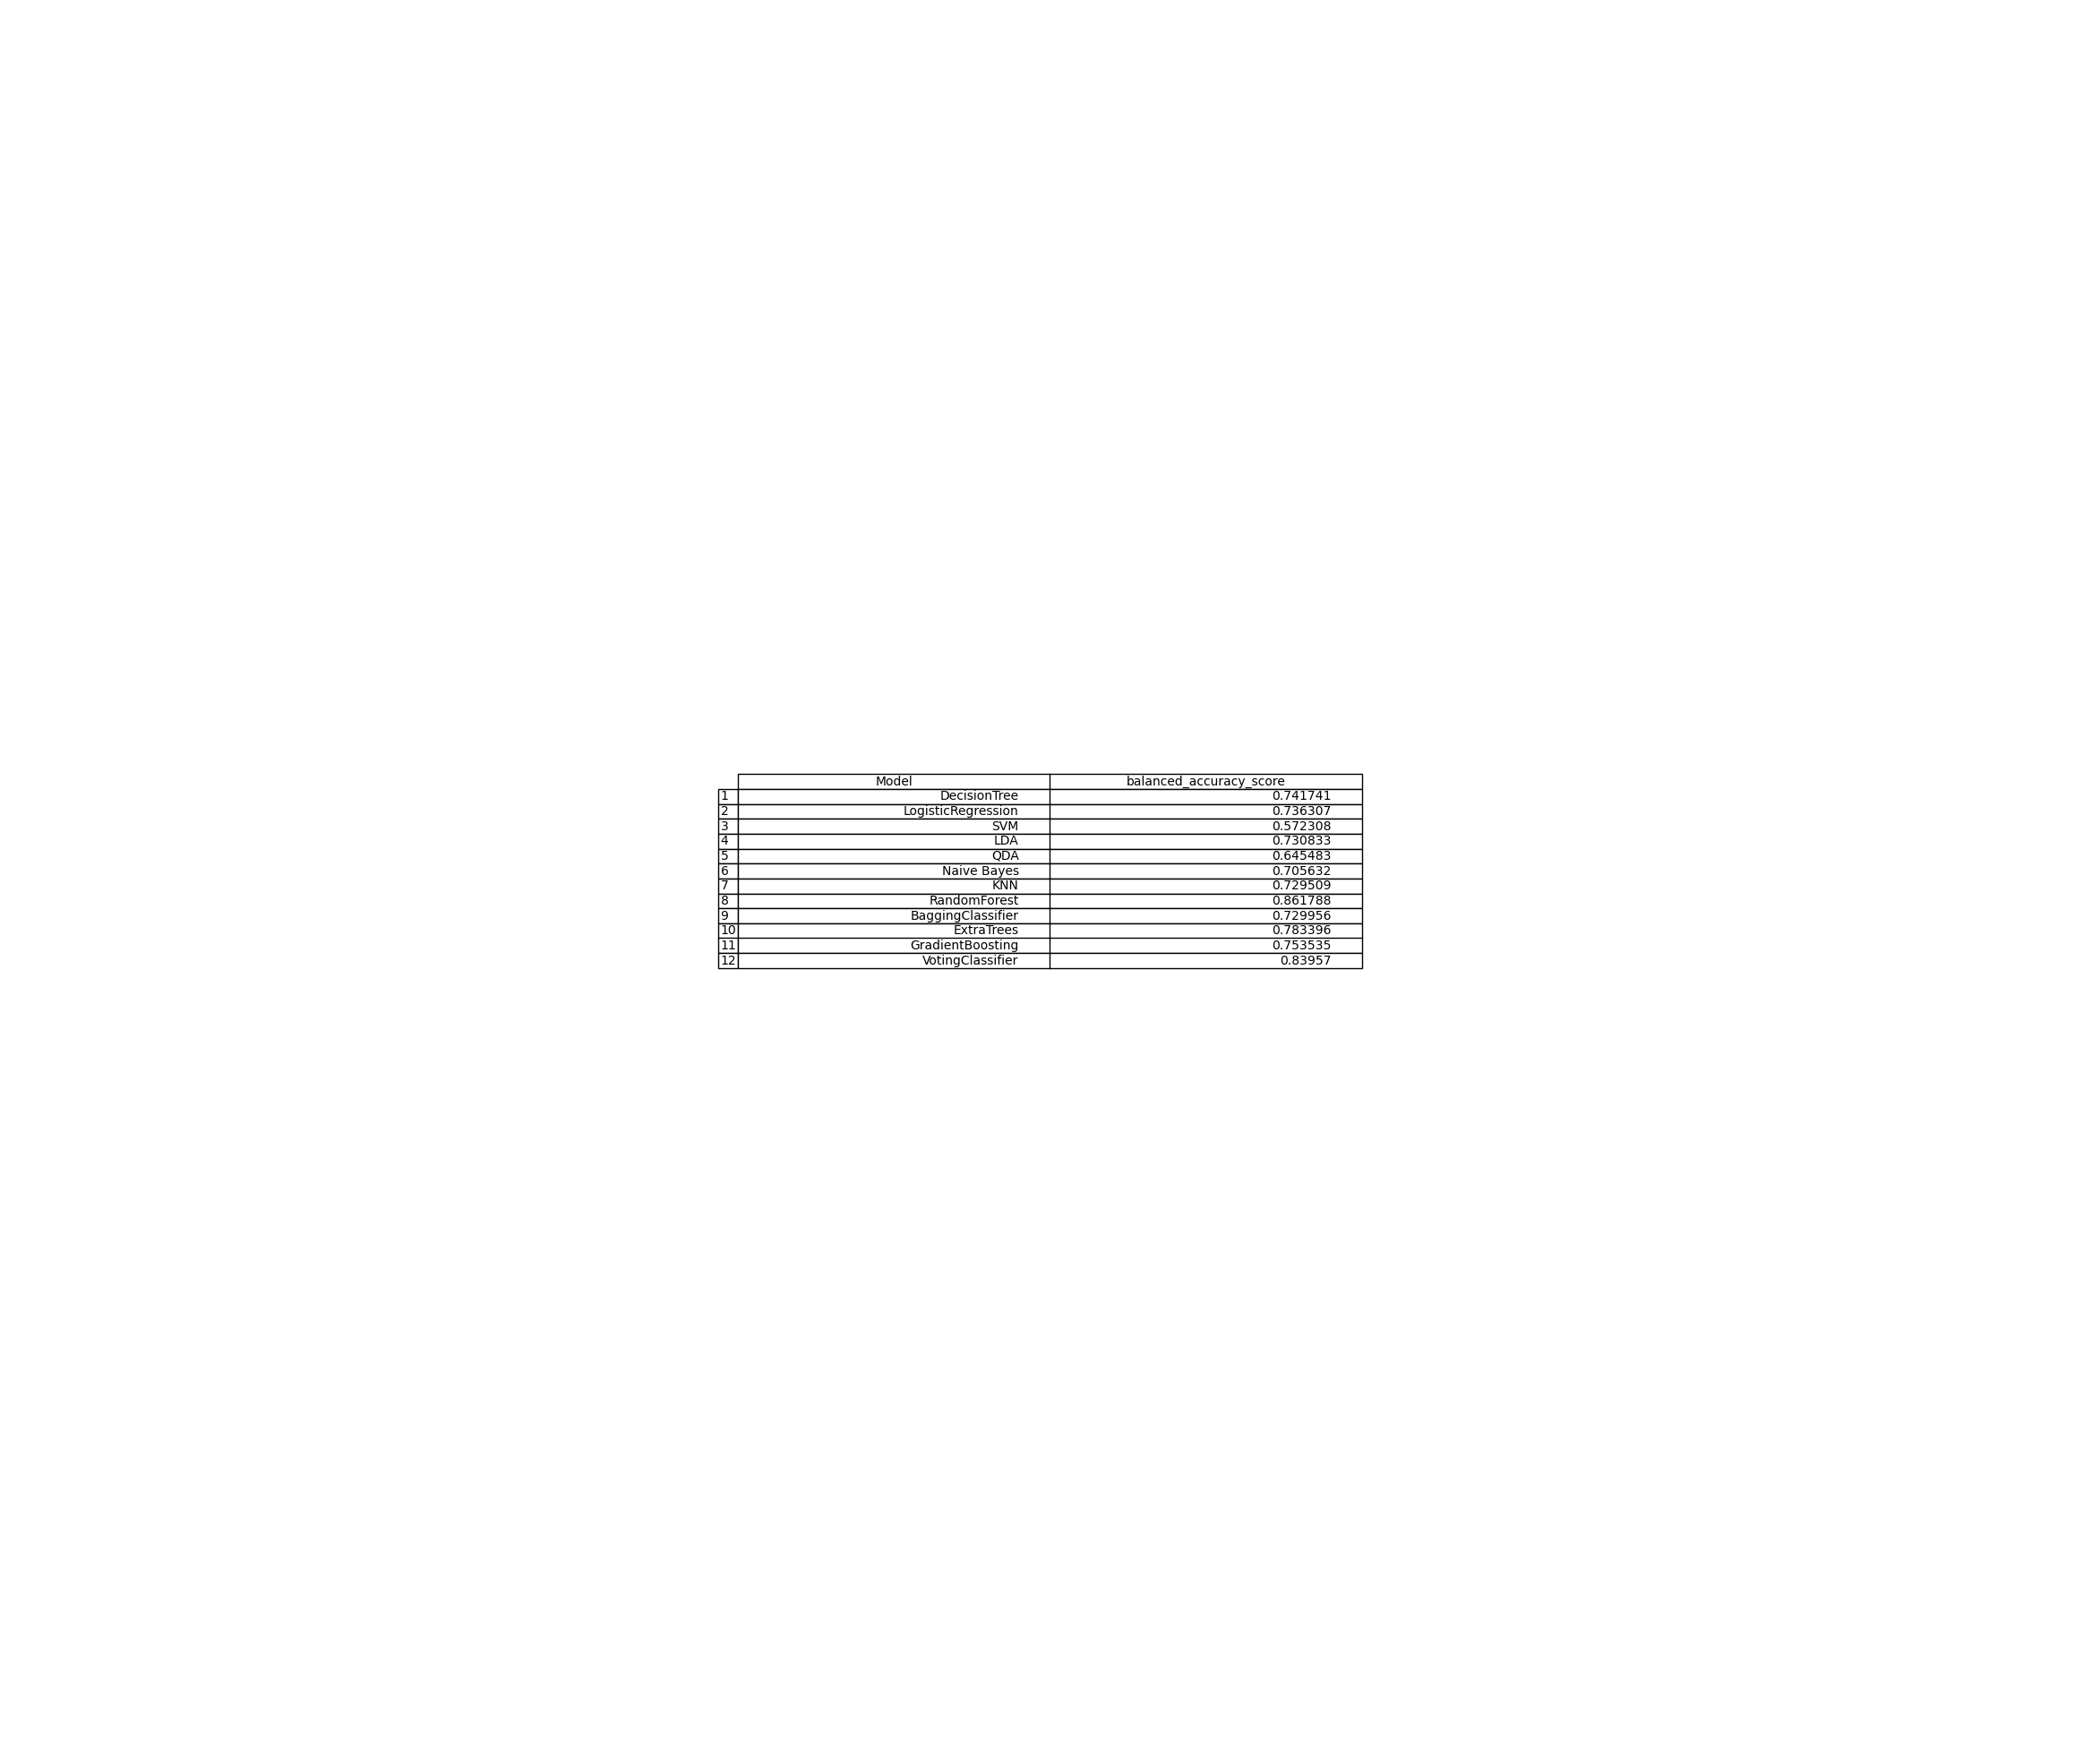

In [51]:
#Wyświetlanie tabeli

fig, ax = plt.subplots(figsize=(30, 25)) #Ustawienie rozmiaru 

ax.axis('off') #Usuwamy oś

table(ax, df_wyniki, loc='center', colWidths=[0.15]*len(df_wyniki.columns)) #Wyświetlanie tabeli

plt.savefig('df_wyniki.png', bbox_inches='tight', dpi=500) #Zapisywanie

Policzmy jeszcze krzywe Roc dla każdego z modeli

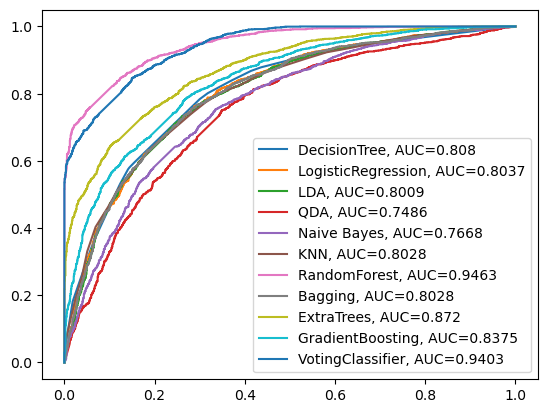

In [129]:
# Wyliczanie krzywej ROC bez SVM (bo nie mają predict_proba)

#Predykcja modeli
pred1 = pipeline_DecisionTree.predict_proba(X_train)
pred2 = pipeline_LogisticRegression.predict_proba(X_train)
pred4 = pipeline_lda.predict_proba(X_train)

pred5 = pipeline_qda.predict_proba(X_train)
pred6 = pipeline_bayes.predict_proba(X_train)
pred7 = pipeline_knn.predict_proba(X_train)
pred8 = pipeline_forest.predict_proba(X_train)

pred9 = pipeline_bagging.predict_proba(X_train)
pred10 = pipeline_extratrees.predict_proba(X_train)
pred11 = pipeline_gradientboosting.predict_proba(X_train)
pred12 = pipeline_votingclassifier.predict_proba(X_train)


#Krzywe ROC
fpr, tpr, thresholds = roc_curve(y_train, pred1[:,1])
plt.plot(fpr,tpr,label="DecisionTree, AUC="+str(round(roc_auc_score(y_train, pred1[:,1]), 4)))
fpr, tpr, thresholds = roc_curve(y_train, pred2[:,1])
plt.plot(fpr,tpr,label="LogisticRegression, AUC="+str(round(roc_auc_score(y_train, pred2[:,1]), 4)))
fpr, tpr, thresholds = roc_curve(y_train, pred4[:,1])
plt.plot(fpr,tpr,label="LDA, AUC="+str(round(roc_auc_score(y_train, pred4[:,1]), 4)))

fpr, tpr, thresholds = roc_curve(y_train, pred5[:,1])
plt.plot(fpr,tpr,label="QDA, AUC="+str(round(roc_auc_score(y_train, pred5[:,1]), 4)))
fpr, tpr, thresholds = roc_curve(y_train, pred6[:,1])
plt.plot(fpr,tpr,label="Naive Bayes, AUC="+str(round(roc_auc_score(y_train, pred6[:,1]), 4)))
fpr, tpr, thresholds = roc_curve(y_train, pred7[:,1])
plt.plot(fpr,tpr,label="KNN, AUC="+str(round(roc_auc_score(y_train, pred7[:,1]), 4)))
fpr, tpr, thresholds = roc_curve(y_train, pred8[:,1])
plt.plot(fpr,tpr,label="RandomForest, AUC="+str(round(roc_auc_score(y_train, pred8[:,1]), 4)))

fpr, tpr, thresholds = roc_curve(y_train, pred9[:,1])
plt.plot(fpr,tpr,label="Bagging, AUC="+str(round(roc_auc_score(y_train, pred9[:,1]), 4)))
fpr, tpr, thresholds = roc_curve(y_train, pred10[:,1])
plt.plot(fpr,tpr,label="ExtraTrees, AUC="+str(round(roc_auc_score(y_train, pred10[:,1]), 4)))
fpr, tpr, thresholds = roc_curve(y_train, pred11[:,1])
plt.plot(fpr,tpr,label="GradientBoosting, AUC="+str(round(roc_auc_score(y_train, pred11[:,1]), 4)))
fpr, tpr, thresholds = roc_curve(y_train, pred12[:,1])
plt.plot(fpr,tpr,label="VotingClassifier, AUC="+str(round(roc_auc_score(y_train, pred12[:,1]), 4)))

plt.legend()
plt.savefig('roc_auc.png', bbox_inches='tight', dpi=500) #Zapisywanie
plt.show()

In [133]:
array=pipeline_forest.predict_proba(X_test)[:,1]
np.savetxt("output_forest.txt", array.reshape(-1, 1), fmt="%.15f") #zapisywanie do pliku

Policzmy balanced_accuracy dla modelu domyślnego RandomForest

In [136]:
#Model domyślny
numerical_transformer = Pipeline([
    ('imputer', SimpleImputer()),
    ('scaler', StandardScaler())
]) #Uzupełnianie braków danych i skalowanie zmiennych numerycznych

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer()),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
]) #Uzupełnianie braków danych i kodowanie zmiennych kategorycznych

preprocessor = ColumnTransformer([
    ('numerical', numerical_transformer, numerical_features),
    ('categorical', categorical_transformer, categorical_features)
]) #przetwarzanie

pipeline_forest_basic= Pipeline([
    ('pre', preprocessor),
    ('tree', RandomForestClassifier())
]) #Złączenie w pipeline modelu i przetwarzania danych

In [138]:
pipeline_forest_basic.fit(X_train, y_train.RiskPerformance)

Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['X1', 'X2', 'X3', 'X4', 'X5',
                                                   'X6', 'X7', 'X8', 'X9',
                                                   'X12', 'X13', 'X14', 'X15',
                                                   'X16', 'X17', 'X18', 'X19',
                                                   'X20', 'X21', 'X22',
                                                   'X23']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['X10', 'X11'])])),
                ('tree', RandomForestClassifier())])

In [144]:
y_pred_train=pipeline_forest_basic.predict(X_train) #Predykcja na zbiorze treningowym

In [146]:
balanced_accuracy_score(y_train.RiskPerformance, y_pred_train) #Obliczenie balanced_accuracy

0.976094470046083

Model najpewniej się przeuczył i może nie osiągnąć tak dobrego wyniku na danych testowych.